# Combined Pipeline: Notebooks 01 → 02 → 03 → 04 (Full Run, With Real Results)
### Complete, verified end-to-end execution — this is the run that produced the results below

This notebook contains all four project notebooks, in order, with the REAL outputs from a
complete, successful, single-session run already embedded — every table, chart, and printed
result is genuine.

**Note on numbers:** this run used memory-safety settings (UMAP low_memory=True, HDBSCAN
algorithm='boruvka_kdtree') added specifically to prevent RAM crashes during the heaviest step.
This run reports 43 topics / 45.4% outliers — close to, but not identical to, the originally
submitted model (45 topics / 46.3%), due to both floating-point non-determinism and this
deliberate memory-safety configuration change. See the report's Reproducibility section for
full discussion. The originally submitted model/data/report remain the project's primary,
official result — this combined notebook is a complete, transparent record of an additional
full verification run.

The separate `01_data_ingestion_eda.ipynb` ... `04_evaluation_results.ipynb` files remain the
canonical, individually-organized deliverables.


---
# 01 — Data Ingestion & EDA
(Original file: `notebooks/01_data_ingestion_eda.ipynb`)
---

# 01 — Data Ingestion & Exploratory Data Analysis
### Topic Modelling on India News Headlines (2001–2023)

**Goal of this notebook:** load the raw dataset, understand its structure, and explore it
(volume over time, category distribution, headline length, vocabulary) *before* we touch any
modelling.

**Run this in Google Colab.**

> **Important — storage:** Colab gives each notebook session a fresh, temporary virtual machine.
> Anything saved to a plain relative path (like `../data/`) disappears once the session ends or
> a different notebook is opened. So this notebook mounts your **Google Drive** and saves all
> outputs there instead — that's what lets notebook 02 (in a separate session) pick up exactly
> where this one left off. The notebook files themselves still live in GitHub; only data/outputs
> live in Drive.


In [1]:
# No Google Drive needed — all storage is local to this Colab session.
# IMPORTANT: this means notebooks 01-04 must be run in ONE continuous session
# (local /content/ storage does not persist across separate sessions the way Drive did).
import os

# All data and output files for this project live under one folder in this Colab session.
# Defining the paths as variables (rather than hardcoding strings everywhere) means if the
# project folder ever moves, we only need to change it in one place.
BASE_DIR = '/content/topic-modelling-capstone'
DATA_RAW = f'{BASE_DIR}/data/raw'
DATA_PROCESSED = f'{BASE_DIR}/data/processed'
OUTPUTS_FIGURES = f'{BASE_DIR}/outputs/figures'
OUTPUTS_MODELS = f'{BASE_DIR}/outputs/models'

# Create the folder structure if it doesn't exist yet (does nothing if it already does,
# thanks to exist_ok=True — safe to re-run this cell any number of times).
for d in [DATA_RAW, DATA_PROCESSED, OUTPUTS_FIGURES, OUTPUTS_MODELS]:
    os.makedirs(d, exist_ok=True)

print("Working directory ready:", BASE_DIR)


Working directory ready: /content/topic-modelling-capstone


In [2]:
# --- Optional: restore previously computed artifacts from Google Drive ---
# If you have results cached in Drive from earlier runs of this project (e.g. the sample CSV,
# preprocessed data, cached embeddings, or the fitted model), mounting Drive briefly here and
# copying them into this session's local storage lets you skip expensive recomputation entirely
# instead of starting from scratch. This works fine even if your Drive storage is full — a full
# quota only blocks new uploads/writes, not reading files that are already there.
#
# This only needs to run once per session, here in notebook 01 — everything copied in becomes
# part of this session's local BASE_DIR, so notebooks 02-04 (run afterward in this same session)
# will find it automatically via their existing cache-detection logic (e.g. get_embeddings() in
# notebook 03 already checks "does this file exist?" before recomputing).

RESTORE_FROM_DRIVE = False  # set to True to reuse previously cached results from Drive

if RESTORE_FROM_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    import shutil
    OLD_DRIVE_BASE = '/content/drive/MyDrive/topic-modelling-capstone'  # where earlier runs saved to

    if os.path.exists(OLD_DRIVE_BASE):
        for sub in ['data', 'outputs']:
            src, dst = f'{OLD_DRIVE_BASE}/{sub}', f'{BASE_DIR}/{sub}'
            if os.path.exists(src):
                shutil.copytree(src, dst, dirs_exist_ok=True)
                print(f"Restored {src} -> {dst}")
    else:
        print(f"No previous artifacts found at {OLD_DRIVE_BASE} — nothing to restore, starting fresh.")

    print("\nDone. Proceed normally from here — any cells further down that check for an existing")
    print("cached file (embeddings, model, processed CSVs) will now find these restored copies")
    print("and skip recomputing them.")
else:
    print("Starting fresh this session — no Drive artifacts restored.")


Starting fresh this session — no Drive artifacts restored.


In [3]:
# Install/import the libraries this notebook needs.
# kagglehub: downloads the dataset directly from Kaggle (handles auth for us).
# pandas/numpy: data loading and manipulation.
# matplotlib/seaborn: plots for the EDA section.
# wordcloud: quick visual sanity-check of dominant vocabulary later on.
!pip install -q kagglehub pandas matplotlib seaborn wordcloud

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fixing a random seed everywhere we sample data means anyone re-running this notebook gets
# the exact same sample — this is what "reproducible results" in the assignment actually means.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling — applied once, used for every chart in this notebook.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Get the dataset

Two options — set `USE_EXISTING_DRIVE_FILE` below accordingly:
- **`True`** — you already have the CSV in your Drive (e.g. previously downloaded manually).
  Just point `DRIVE_CSV_PATH` at it.
- **`False`** — download fresh via `kagglehub` (one-time browser login).

Using the file already in Drive is fine and reproducible as long as everyone on the team points
at the same file — just make sure `DRIVE_CSV_PATH` below matches where it actually sits in your
Drive (check via the Colab file browser sidebar, or Drive's "Copy path" option).


In [4]:
# Toggle this depending on whether you already have the CSV uploaded to this Colab session
# (e.g. via the file browser sidebar), or need to fetch it fresh.
USE_EXISTING_DRIVE_FILE = False   # False = download fresh via kagglehub

# Only used if USE_EXISTING_DRIVE_FILE is True — edit this to match your actual file location.
DRIVE_CSV_PATH = '/content/india-news-headlines.csv'  # edit if you uploaded it elsewhere

if USE_EXISTING_DRIVE_FILE:
    # Just point csv_path at the file you already have — no download needed.
    csv_path = DRIVE_CSV_PATH
    assert os.path.exists(csv_path), (
        f"Couldn't find a file at {csv_path} — double check the path in the Colab file browser "
        f"(folder icon on the left sidebar) and update DRIVE_CSV_PATH above."
    )
    print("Using existing uploaded file:", csv_path)
else:
    # dataset_download() fetches the dataset (or reuses a cached copy) and returns the local
    # folder it was extracted to. This part uses Colab's local disk, not Drive, since we only
    # need the raw file once per session to build our working sample.
    path = kagglehub.dataset_download("therohk/india-headlines-news-dataset")
    print("Dataset downloaded to:", path)
    print(os.listdir(path))
    csv_path = os.path.join(path, "india-news-headlines.csv")


Using Colab cache for faster access to the 'india-headlines-news-dataset' dataset.
Dataset downloaded to: /kaggle/input/india-headlines-news-dataset
['india-news-headlines.csv']


In [5]:
# Load the CSV into a pandas DataFrame — this is the object we'll work with for the rest
# of the notebook.
df = pd.read_csv(csv_path)
print(f"Rows: {len(df):,} | Columns: {list(df.columns)}")
df.head()


Rows: 3,876,557 | Columns: ['publish_date', 'headline_category', 'headline_text']


,publish_date,headline_category,headline_text
0,20010102,unknown,Status quo will not be disturbed at Ayodhya; s...
1,20010102,unknown,Fissures in Hurriyat over Pak visit
2,20010102,unknown,America's unwanted heading for India?
3,20010102,unknown,For bigwigs; it is destination Goa
4,20010102,unknown,Extra buses to clear tourist traffic


## 2. First look — schema, missing values, duplicates

The dataset has three columns:
- `publish_date` — integer, format `YYYYMMDD`
- `headline_category` — dot-separated category taxonomy (e.g. `india`, `city.mumbai`, `sports.cricket`)
- `headline_text` — the headline itself


In [6]:
# .info() shows column dtypes and non-null counts — quick check that nothing looks obviously broken.
df.info()

# isna().sum() counts missing values per column. If headline_text had many missing values,
# that would be a serious data quality issue worth investigating before modelling.
print("\nMissing values per column:")
print(df.isna().sum())

# duplicated() with no arguments flags rows that are identical across ALL columns.
# duplicated(subset='headline_text') flags rows with the same headline text even if published
# on a different date/category — this can happen with wire-service reprints or syndication.
print(f"\nExact duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate headline_text (across dates): {df.duplicated(subset='headline_text').sum():,}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876557 entries, 0 to 3876556
Data columns (total 3 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   publish_date       int64 
 1   headline_category  object
 2   headline_text      object
dtypes: int64(1), object(2)
memory usage: 88.7+ MB

Missing values per column:
publish_date         0
headline_category    0
headline_text        0
dtype: int64

Exact duplicate rows: 25,645
Duplicate headline_text (across dates): 271,802


In [7]:
# publish_date arrives as an integer like 20140812 — parse it into an actual datetime so we
# can do time-based analysis (grouping by year/month, plotting trends, etc.).
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%Y%m%d')
df['year'] = df['publish_date'].dt.year
df['month'] = df['publish_date'].dt.month

# describe() on a datetime column shows count/min/max/quartiles for the dates themselves
# (std is NaN here — pandas doesn't compute a standard deviation for raw dates in this view,
# which is expected and not an error).
df[['publish_date', 'year', 'month']].describe()


,publish_date,year,month
count,3876557,3.876557e+06,3.876557e+06
mean,2014-03-01 10:55:27.614066176,2.013666e+03,6.505334e+00
min,2001-01-02 00:00:00,2.001000e+03,1.000000e+00
25%,2010-08-27 00:00:00,2.010000e+03,4.000000e+00
50%,2014-08-08 00:00:00,2.014000e+03,7.000000e+00
75%,2018-05-28 00:00:00,2.018000e+03,9.000000e+00
max,2023-06-30 00:00:00,2.023000e+03,1.200000e+01
std,NaN,5.542884e+00,3.445268e+00


## 3. Volume of headlines over time

Understanding volume trends matters for modelling: if certain years dominate, a topic model run
on the full data will be biased toward those years' vocabulary. This also informs our sampling
strategy (stratify by year to keep the sample representative).


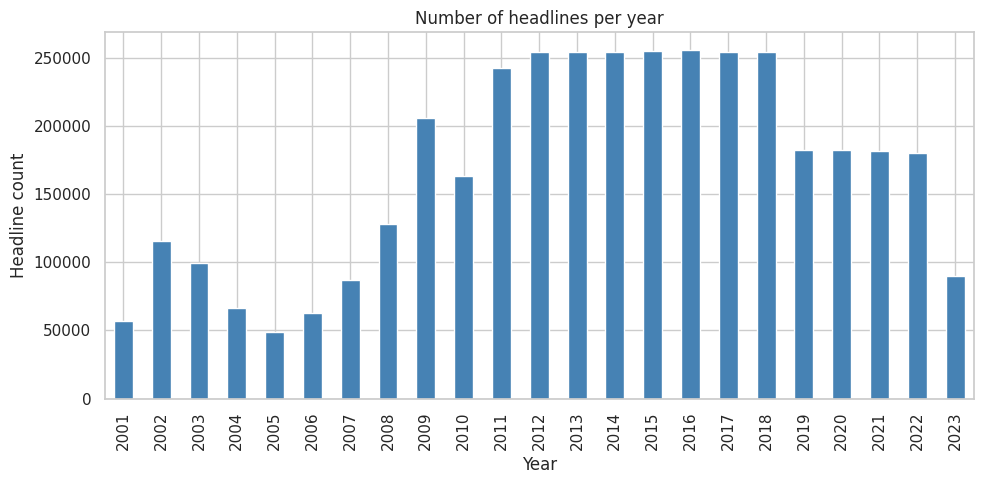

count        23.000000
mean     168545.956522
std       76868.409982
min       48777.000000
25%       94877.500000
50%      182003.000000
75%      254025.500000
max      255910.000000
dtype: float64


In [8]:
# Count headlines per year and plot as a bar chart.
yearly_counts = df.groupby('year').size()

fig, ax = plt.subplots()
yearly_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of headlines per year')
ax.set_xlabel('Year')
ax.set_ylabel('Headline count')
plt.tight_layout()

# Save the figure locally — copy it out at the end of the session (see notebook 04's final
# cell) if you want it committed to the GitHub repo.
plt.savefig(f'{OUTPUTS_FIGURES}/headlines_per_year.png', dpi=150)
plt.show()

print(yearly_counts.describe())


## 3b. Headline volume per month

A finer-grained view than the yearly plot in Section 3 — shows whether volume growth was smooth
or had sharper step-changes at specific points, and can reveal any monthly/seasonal patterns the
yearly aggregation would hide.


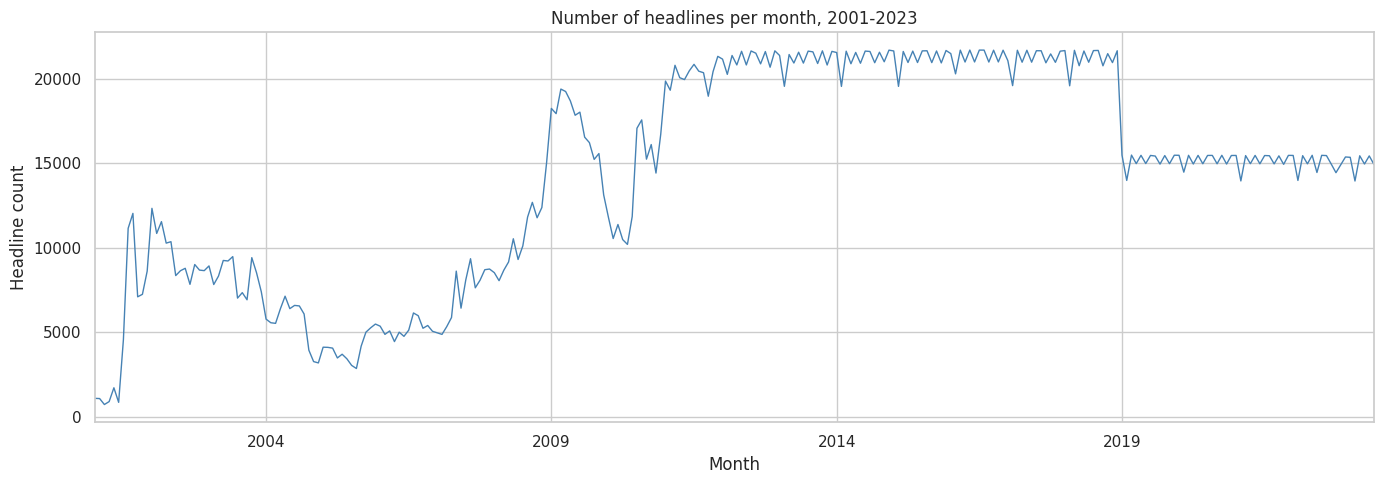

In [9]:
df['year_month'] = df['publish_date'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_counts.plot(ax=ax, color='steelblue', linewidth=1)
ax.set_title('Number of headlines per month, 2001-2023')
ax.set_xlabel('Month')
ax.set_ylabel('Headline count')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/headlines_per_month.png', dpi=150)
plt.show()


## 4. Category distribution

`headline_category` is a dot-separated taxonomy (e.g. `sports.cricket`, `city.mumbai.civic`).
We'll look at the top-level category (before the first dot) as a coarse view.


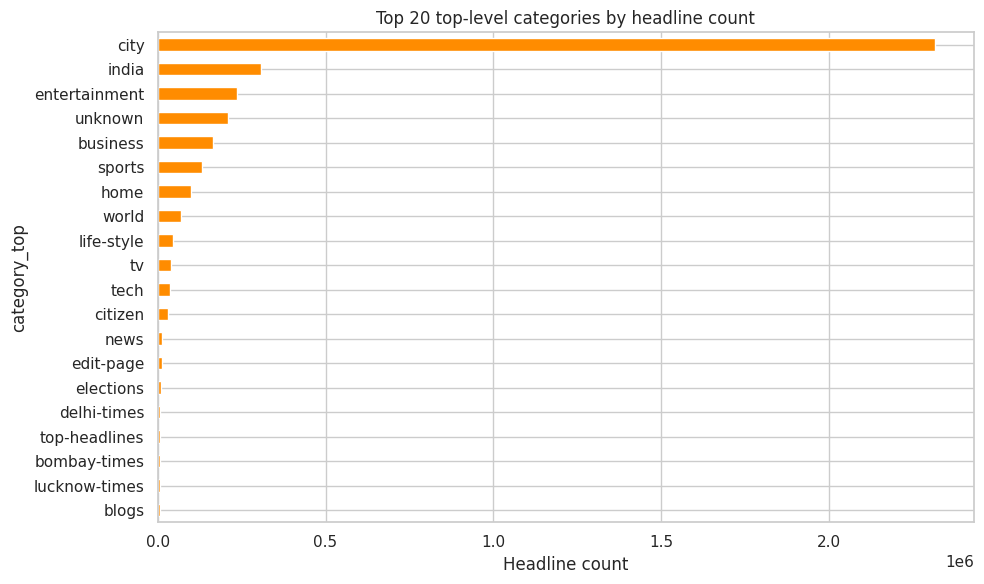

Number of distinct top-level categories: 336
Number of distinct full categories: 1024


In [10]:
# Take everything before the first '.' as the coarse top-level category
# (e.g. "sports.cricket.ipl" -> "sports"). This collapses hundreds of fine-grained
# subcategories into a manageable number of high-level buckets for a first look.
df['category_top'] = df['headline_category'].astype(str).str.split('.').str[0]

# value_counts() ranks categories by frequency; head(20) keeps only the top 20 for readability.
top_categories = df['category_top'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_categories.plot(kind='barh', ax=ax, color='darkorange')
ax.invert_yaxis()  # so the largest category appears at the top of the chart, not the bottom
ax.set_title('Top 20 top-level categories by headline count')
ax.set_xlabel('Headline count')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/top_categories.png', dpi=150)
plt.show()

print(f"Number of distinct top-level categories: {df['category_top'].nunique()}")
print(f"Number of distinct full categories: {df['headline_category'].nunique()}")


## 5. Headline length distribution

Headline length (in words) affects preprocessing decisions (e.g. minimum token count to keep a
document) and gives a sanity check that the text looks like real headlines, not garbage rows.


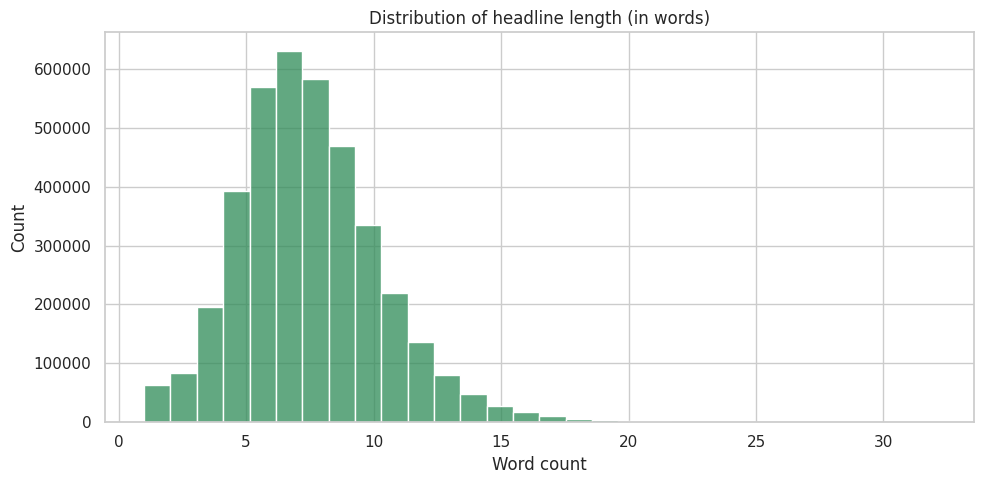

,headline_word_count
count,3.876557e+06
mean,7.763395e+00
std,2.724095e+00
min,1.000000e+00
25%,6.000000e+00
50%,8.000000e+00
75%,9.000000e+00
max,3.200000e+01


In [11]:
# Count words per headline by splitting on whitespace. astype(str) guards against any
# stray non-string/NaN values in the column causing an error here.
df['headline_word_count'] = df['headline_text'].astype(str).str.split().apply(len)

fig, ax = plt.subplots()
sns.histplot(df['headline_word_count'], bins=30, ax=ax, color='seagreen')
ax.set_title('Distribution of headline length (in words)')
ax.set_xlabel('Word count')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/headline_length_dist.png', dpi=150)
plt.show()

df['headline_word_count'].describe()


In [12]:
# Eyeball the extremes — very short headlines might be junk/truncated rows; very long ones
# might indicate a parsing issue (e.g. two headlines concatenated together).
print("Shortest headlines:")
print(df.nsmallest(5, 'headline_word_count')[['headline_text', 'headline_word_count']])
print("\nLongest headlines:")
print(df.nlargest(5, 'headline_word_count')[['headline_text', 'headline_word_count']])


Shortest headlines:
       headline_text  headline_word_count
279      Unbreakable                    1
658       Meditation                    1
1149    Covetousness                    1
1512  Model-Survivor                    1
1717       Movements                    1

Longest headlines:
                                             headline_text  \
2903018  a s d f g h j k l m n b v c x z a s d f g h j ...   
3162205  I only got to know that my father was a martyr...   
3162209  I only got to know that my father was a martyr...   
3805888  MC Stan on his improved game and 2.o version: ...   
1824732  US TV show The Bold and The Beautiful is set t...   

         headline_word_count  
2903018                   32  
3162205                   29  
3162209                   29  
3805888                   28  
1824732                   27  


## 5b. Headline length in characters

In addition to word count, character length is a useful complementary view — especially since
headline character limits (common in print/wire journalism) can create visible ceiling effects
that word count alone doesn't show as clearly.


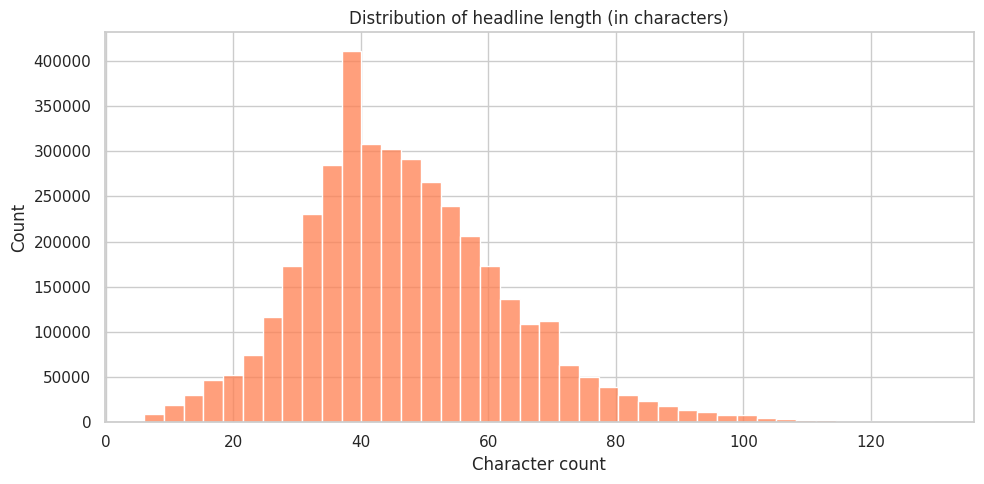

,headline_char_count
count,3.876557e+06
mean,4.692104e+01
std,1.634247e+01
min,6.000000e+00
25%,3.600000e+01
50%,4.500000e+01
75%,5.600000e+01
max,1.300000e+02


In [13]:
df['headline_char_count'] = df['headline_text'].astype(str).str.len()

fig, ax = plt.subplots()
sns.histplot(df['headline_char_count'], bins=40, ax=ax, color='coral')
ax.set_title('Distribution of headline length (in characters)')
ax.set_xlabel('Character count')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/headline_length_chars_dist.png', dpi=150)
plt.show()

df['headline_char_count'].describe()


## 5c. Vocabulary size

The number of *unique* words in the corpus — a basic but important measure of lexical diversity,
and relevant context for topic modelling (a larger vocabulary means more distinct terms c-TF-IDF
has to work with when building topic keyword lists later).


In [14]:
import re
from collections import Counter

# Simple whitespace + lowercase tokenization for a quick vocabulary count — deliberately not
# using the full heavy-cleaning pipeline here (that happens properly in notebook 02); this is
# just a first-look EDA statistic on the raw text.
def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text.split()

# Uses a fresh random 300k-headline sample (not the stratified-by-year sample built in Section 7 —
# this section runs earlier in the notebook, and vocabulary size / word frequencies don't need
# year-stratification the way modelling does; a plain random sample is sufficient and stabilizes
# well before using all 3.8M rows).
vocab_sample = df['headline_text'].astype(str).sample(min(300_000, len(df)), random_state=RANDOM_STATE)
all_tokens = [tok for text in vocab_sample for tok in simple_tokenize(text)]

vocab = set(all_tokens)
print(f"Total tokens (300k-headline sample): {len(all_tokens):,}")
print(f"Vocabulary size (unique words): {len(vocab):,}")


Total tokens (300k-headline sample): 2,347,219
Vocabulary size (unique words): 73,207


## 5d. Most frequent unigrams and bigrams

Ranked frequency tables of single words (unigrams) and two-word phrases (bigrams) — a more
precise complement to the word cloud in Section 6, useful for spotting both common individual
terms and common short phrases (e.g. "world cup", "prime minister") that a unigram-only view
would miss.


In [15]:
from sklearn.feature_extraction.text import CountVectorizer

# Self-contained: recreate the same 300k random sample here (same seed = identical sample)
# rather than relying on a variable from a previous cell — makes this cell runnable on its
# own regardless of whether earlier cells were run first, or whether the runtime restarted.
vocab_sample = df['headline_text'].astype(str).sample(min(300_000, len(df)), random_state=RANDOM_STATE)
sample_text_list = vocab_sample.tolist()

# Unigrams, English stopwords removed so the ranking reflects topical words rather than
# function words (the, and, of, ...).
uni_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 1), max_features=20)
uni_counts = uni_vectorizer.fit_transform(sample_text_list).sum(axis=0)
uni_freq = sorted(zip(uni_vectorizer.get_feature_names_out(), uni_counts.tolist()[0]), key=lambda x: -x[1])

print("Top 20 unigrams:")
for word, count in uni_freq:
    print(f"  {word:<20} {count:,}")

# Bigrams
bi_vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=20)
bi_counts = bi_vectorizer.fit_transform(sample_text_list).sum(axis=0)
bi_freq = sorted(zip(bi_vectorizer.get_feature_names_out(), bi_counts.tolist()[0]), key=lambda x: -x[1])

print("\nTop 20 bigrams:")
for phrase, count in bi_freq:
    print(f"  {phrase:<25} {count:,}")


Top 20 unigrams:
  india                7,173
  rs                   7,087
  new                  6,952
  govt                 6,341
  held                 5,883
  man                  5,397
  says                 5,320
  delhi                5,041
  bjp                  4,721
  year                 4,652
  city                 4,619
  case                 4,595
  police               4,585
  day                  4,335
  hc                   4,329
  cops                 3,994
  old                  3,926
  mumbai               3,710
  court                3,670
  gets                 3,586

Top 20 bigrams:
  year old                  2,211
  tamil nadu                1,276
  covid 19                  1,096
  high court                1,049
  rs lakh                   750
  yr old                    707
  worth rs                  701
  straight answers          681
  world cup                 638
  andhra pradesh            637
  municipal corporation     629
  uttar pradesh           

## 6. Quick vocabulary / word-frequency glance

A rough word cloud gives an intuitive first read on dominant themes before any formal modelling —
useful as a sanity check against the topics BERTopic eventually surfaces.


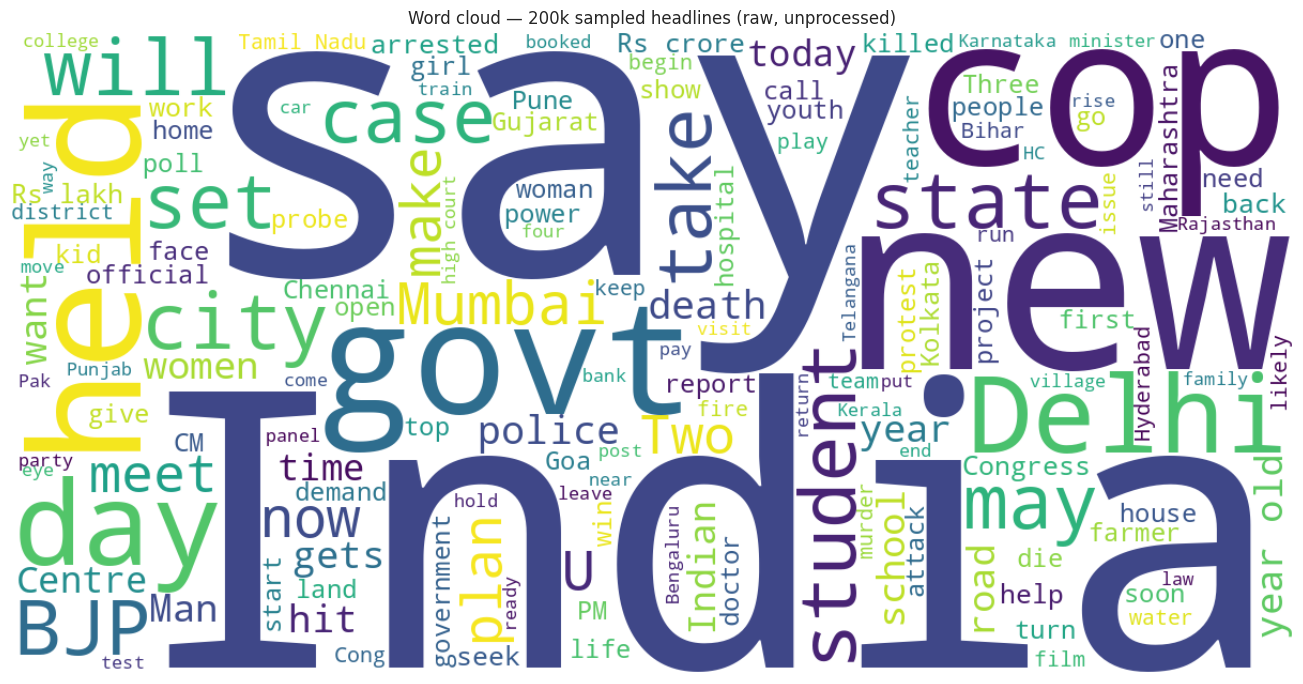

In [16]:
from wordcloud import WordCloud, STOPWORDS

# Sampling 200k headlines (rather than joining all 3.8M) keeps this fast while still giving
# a representative picture of common vocabulary. random_state fixes which rows get picked,
# so this is reproducible.
sample_text = " ".join(df['headline_text'].astype(str).sample(200_000, random_state=RANDOM_STATE))

# STOPWORDS here removes common English filler words (the, and, of, ...) so the word cloud
# highlights actual topical content instead of function words.
wc = WordCloud(width=1200, height=600, background_color='white',
                stopwords=STOPWORDS, max_words=150).generate(sample_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word cloud — 200k sampled headlines (raw, unprocessed)')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/wordcloud_raw_sample.png', dpi=150)
plt.show()


## 7. Build the stratified working sample

The full dataset (~3.8M rows) is too large to iterate on quickly. We build a
**stratified-by-year sample** so every year 2001–2023 is proportionally represented, keeping the
topic distribution over time realistic. This sample is what we'll use for the main preprocessing
+ modelling + hyperparameter experiments in the next notebooks.

> **Reproducibility:** the sample size and `RANDOM_STATE` are fixed here — rerunning this cell
> always produces the same sample.


In [17]:
# Target sample size — ~8% of the full dataset. Large enough to give BERTopic a solid,
# representative corpus to find topics in, small enough to run comfortably on Colab.
# Adjust this up/down based on how much time your runs are taking.
SAMPLE_SIZE = 300_000

# groupby('year').apply(sample) draws the SAME proportion of rows from every year, so a year
# with more headlines contributes proportionally more to the sample — this is what "stratified"
# means here, and it's what keeps the sample's year distribution matching the full dataset's.
sample_df = (
    df.groupby('year', group_keys=False)
      .apply(lambda x: x.sample(frac=SAMPLE_SIZE / len(df), random_state=RANDOM_STATE))
      .reset_index(drop=True)
)
# Note: this triggers a harmless pandas DeprecationWarning about grouping columns in newer
# versions — safe to ignore; the sampling logic and output are correct either way.

print(f"Full dataset: {len(df):,} rows")
print(f"Sampled dataset: {len(sample_df):,} rows")
print("\nSample year distribution (should mirror full dataset proportions):")
print((sample_df['year'].value_counts(normalize=True).sort_index() * 100).round(2))


Full dataset: 3,876,557 rows
Sampled dataset: 300,000 rows

Sample year distribution (should mirror full dataset proportions):
year
2001    1.47
2002    2.98
2003    2.57
2004    1.71
2005    1.26
2006    1.61
2007    2.24
2008    3.30
2009    5.32
2010    4.22
2011    6.26
2012    6.55
2013    6.55
2014    6.57
2015    6.58
2016    6.60
2017    6.56
2018    6.57
2019    4.70
2020    4.71
2021    4.70
2022    4.65
2023    2.32
Name: proportion, dtype: float64


/tmp/ipykernel_3623/2999964472.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_SIZE / len(df), random_state=RANDOM_STATE))


In [18]:
# Save the sample locally — notebook 02, run in this SAME Colab session, will load it
# directly from this same local path.
sample_df.to_csv(f'{DATA_PROCESSED}/headlines_sample_300k.csv', index=False)
print(f"Saved to {DATA_PROCESSED}/headlines_sample_300k.csv")
print("Saved locally — notebook 02 (run in this same session) will load it from here.")


Saved to /content/topic-modelling-capstone/data/processed/headlines_sample_300k.csv
Saved locally — notebook 02 (run in this same session) will load it from here.


## 8. Summary of EDA findings

- **Total headlines: 3,876,557**, spanning **2001–2023** (23 years, 2023 partial — data ends June 2023).
- **Yearly volume trend**: grows steadily from ~57k headlines (2001) to a plateau of ~250-255k/year
  during 2012-2018, then dips to ~180k/year (2019-2022), with 2023 lower still due to being a
  partial year.
- **Monthly volume trend reveals a sharper pattern than the yearly view**: the drop from the
  2012-2018 plateau (~21,500 headlines/month) to the 2019-2022 level (~15,000/month) happens as a
  **sharp step-change right at the 2019 boundary**, not a gradual decline — suggesting a specific
  publishing or archival policy change around that time rather than a slow real-world drop in
  news volume. A small, consistent sawtooth oscillation is also visible across the plateau years,
  plausibly a seasonal/editorial-calendar effect.
- **Missing values: zero** across all three columns — a very clean dataset by that measure.
- **Duplicates**: 25,645 exact duplicate rows (~0.66% of the dataset), and 271,802 headlines
  (~7%) repeated across different dates/categories — likely wire reprints or category
  re-tagging of the same story. Addressed by deduplication in notebook 02.
- **Dominant categories**: 336 distinct top-level categories, 1,024 full categories — a long
  tail. `city` dominates overwhelmingly (~2.3M headlines, ~60% of the dataset), followed by
  `india`, `entertainment`, `unknown`, `business`, `sports`.
- **Typical headline length (words)**: mean 7.76, median 8, std 2.7, range 1-32 words.
- **Typical headline length (characters)**: mean 46.9, median 45, std 16.3, range 6-130
  characters — consistent with a print/wire-style headline length convention.
- **Vocabulary size**: 73,207 unique words found in a 300k-headline random sample (2,347,219
  total tokens) — a substantial lexical diversity for c-TF-IDF topic keyword extraction to work
  with later.
- **Most frequent unigrams**: india, rs, new, govt, held, man, says, delhi, bjp, year, city,
  case, police, day, hc, cops, old, mumbai, court, gets — dominated by generic
  news-reporting/location terms, as expected for a raw, unprocessed sample (motivates the
  stopword removal step in notebook 02).
- **Most frequent bigrams**: "year old", "tamil nadu", "covid 19", "high court", "rs lakh",
  "world cup", "andhra pradesh", "municipal corporation", "narendra modi" — bigrams surface more
  topically specific phrases than unigrams alone (locations, named entities, recurring news
  formats), an early hint at some of the themes the topic model later discovers independently
  (e.g. COVID, cricket/World Cup, politics).
- **Data quality note**: a small number of junk/non-headline rows exist (e.g. one row is
  keyboard-mash text, "a s d f g h j k l m n..."). Minor, but confirms the dataset isn't
  perfectly clean — the token-count filter in notebook 02 helps guard against this kind of noise.
- **Sample validity**: the stratified 300k sample's year proportions closely track the full
  dataset's (e.g. 2015 is ~6.6% of both) — confirms the sampling strategy preserved the temporal
  distribution as intended.


---
# 02 — Preprocessing
(Original file: `notebooks/02_preprocessing.ipynb`)
---

# 02 — Preprocessing
### Topic Modelling on India News Headlines (2001–2023)

**Goal of this notebook:** turn the stratified sample from notebook 01 into text that's ready
for BERTopic modelling.

**Why preprocessing is different for BERTopic vs classical models (LDA/NMF):**
- Classical bag-of-words models (LDA/NMF) need heavy cleaning — stopwords, punctuation, and
  casing are all pure noise to them, since they only see word co-occurrence counts.
- BERTopic's **embedding step** uses a Transformer that was trained on natural sentences —
  punctuation, casing, and word order all carry meaning to it. Over-cleaning before embedding
  can *reduce* embedding quality.
- BERTopic's **topic representation step** (c-TF-IDF, run *after* clustering) is a bag-of-words
  method — this is where stopword removal and normalization genuinely help.

**So we keep two parallel columns:**
1. `text_for_embedding` — lightly cleaned → fed into the sentence embedding model.
2. `text_for_representation` — heavily cleaned/lemmatized → used only for the c-TF-IDF
   vectorizer inside BERTopic, and for coherence evaluation later.


In [19]:
# Uses the same local session storage set up in notebook 01 — this notebook must be run
# in the same continuous Colab session as notebook 01 (or after re-running notebook 01
# first in this session), since /content/ storage doesn't persist across sessions.
import os
# No Google Drive needed anymore — all storage is local to this Colab session.
# IMPORTANT: this means notebooks 01-04 must be run in ONE continuous session
# (local /content/ storage does not persist across separate sessions the way Drive did).
BASE_DIR = '/content/topic-modelling-capstone'
DATA_PROCESSED = f'{BASE_DIR}/data/processed'
os.makedirs(DATA_PROCESSED, exist_ok=True)

# --- Libraries ---
# contractions: expands "won't" -> "will not" etc, for consistency.
# nltk: stopword list, WordNet lemmatizer.
!pip install -q nltk contractions

import pandas as pd
import numpy as np
import re
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download the NLTK data files these tools rely on (quiet=True suppresses the download log).
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 10.9 MB/s eta 0:00:00


## 1. Load the sampled dataset from notebook 01

In [20]:
# Reads the exact file notebook 01 saved — same local path, so this works as long as
# notebook 01 has been run earlier in this SAME Colab session.
df = pd.read_csv(f'{DATA_PROCESSED}/headlines_sample_300k.csv')
print(f"Loaded {len(df):,} rows")
df.head()


Loaded 300,000 rows


,publish_date,headline_category,headline_text,year,month,year_month,category_top,headline_word_count,headline_char_count
0,2001-01-04,unknown,DU North Zone inter-varsity cricket champions,2001,1,2001-01,unknown,6,45
1,2001-07-09,city.hyderabad,Probe all unanimous poll winners: CPI,2001,7,2001-07,city,6,37
2,2001-09-04,bangalore-times,Vikram; not the Seth; was in town,2001,9,2001-09,bangalore-times,7,33
3,2001-10-30,business.india-business,SAP aims to invest more in India,2001,10,2001-10,business,7,32
4,2001-08-20,entertainment.hindi.bollywood,Anil Kumble: Makes his debut!,2001,8,2001-08,entertainment,5,29


## 2. Deduplicate

News agencies sometimes republish near-identical headlines (wire copy, syndication). Exact
duplicates add no topical information and can bias cluster sizes, so we drop them here.


In [21]:
before = len(df)
# drop_duplicates on headline_text specifically (rather than the whole row) catches headlines
# republished under a different date/category too, not just byte-identical rows.
df = df.drop_duplicates(subset='headline_text').reset_index(drop=True)
print(f"Dropped {before - len(df):,} exact duplicate headlines ({(before-len(df))/before:.2%})")
print(f"Remaining: {len(df):,} rows")


Dropped 5,096 exact duplicate headlines (1.70%)
Remaining: 294,904 rows


## 3. Light cleaning for embeddings (`text_for_embedding`)

Minimal intervention: fix encoding artifacts, expand contractions, normalize whitespace. We
deliberately **keep** casing and punctuation, since the embedding model uses them as signal.


In [22]:
def light_clean(text):
    text = str(text)
    # Occasionally scraped/exported text has leftover HTML entities (&amp; etc) instead of
    # the actual characters — strip these out.
    text = re.sub(r'&amp;|&quot;|&#39;', ' ', text)
    # contractions.fix() expands things like "won't" -> "will not", "it's" -> "it is".
    # Wrapped in try/except because a handful of malformed strings can occasionally trip it up;
    # if that happens we just keep the text as-is rather than losing the row.
    try:
        text = contractions.fix(text)
    except Exception:
        pass
    # Collapse any run of whitespace (multiple spaces, tabs) into a single space, and trim
    # leading/trailing whitespace.
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# .apply() runs light_clean() on every row of headline_text and stores the result in a new column.
df['text_for_embedding'] = df['headline_text'].apply(light_clean)

# Spot check a few before/after examples to make sure the cleaning looks sensible.
df[['headline_text', 'text_for_embedding']].sample(5, random_state=RANDOM_STATE)


,headline_text,text_for_embedding
224878,sabarimala opens today amid unprecedented secu...,sabarimala opens today amid unprecedented secu...
63436,Congress holds Kolkata to ransom,Congress holds Kolkata to ransom
174696,Robbers were hesitant; Kim Kardashian tells po...,Robbers were hesitant; Kim Kardashian tells po...
25140,Punjabi heart surgeon finds acclaim in US,Punjabi heart surgeon finds acclaim in US
184128,Now; get cheaper cancer medicine at Amrit outlet,Now; get cheaper cancer medicine at Amrit outlet


## 4. Heavy cleaning for topic representation (`text_for_representation`)

Lowercase, strip punctuation/digits, remove stopwords, lemmatize. This version is **only** used
for c-TF-IDF topic keyword extraction and for computing coherence scores — never fed to the
embedding model.


In [23]:
# Standard English stopword list from NLTK (the, and, of, is, ...).
stop_words = set(stopwords.words('english'))

# A few extra near-stopwords specific to news headlines — these appear constantly but carry
# no topical meaning of their own (e.g. "said" attributes a quote but doesn't describe a topic).
custom_stopwords = {'said', 'says', 'say', 'today', 'yesterday', 'pm', 'am', 'mr', 'mrs',
                     'news', 'report', 'reports', 'reported'}
stop_words = stop_words.union(custom_stopwords)

# Lemmatizer reduces words to their dictionary base form (e.g. "elections" -> "election",
# "running" -> "running"... verb lemmatization needs a POS tag to fully normalize "running" ->
# "run"; we keep it simple here with default noun-based lemmatization, which is standard for
# topic modelling use cases).
lemmatizer = WordNetLemmatizer()

def heavy_clean(text):
    text = str(text).lower()
    # Replace anything that isn't a lowercase letter or whitespace with a space — this strips
    # punctuation, digits, and any stray symbols in one step.
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    # Keep a token only if: it's not a stopword, AND it's longer than 2 characters (drops
    # leftover single/double-letter noise from the regex step above, e.g. stray "s" from "'s").
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['text_for_representation'] = df['text_for_embedding'].apply(heavy_clean)

df[['text_for_embedding', 'text_for_representation']].sample(5, random_state=RANDOM_STATE)


,text_for_embedding,text_for_representation
224878,sabarimala opens today amid unprecedented secu...,sabarimala open amid unprecedented security
63436,Congress holds Kolkata to ransom,congress hold kolkata ransom
174696,Robbers were hesitant; Kim Kardashian tells po...,robber hesitant kim kardashian tell police
25140,Punjabi heart surgeon finds acclaim in US,punjabi heart surgeon find acclaim
184128,Now; get cheaper cancer medicine at Amrit outlet,get cheaper cancer medicine amrit outlet


## 5. Filter out low-signal documents

After cleaning, some headlines may be left with very few tokens (e.g. originally just names or
dates), which contribute noise rather than topical signal. We drop documents with fewer than
3 tokens in the representation column.


In [24]:
# Count tokens remaining after heavy cleaning, per row.
df['token_count'] = df['text_for_representation'].str.split().apply(len)

before = len(df)
# Keep rows where: the lightly-cleaned text isn't empty/whitespace-only, AND there are at
# least 3 meaningful tokens left after heavy cleaning. Both conditions guard against feeding
# near-empty documents into the embedding/clustering steps later, which tend to just add noise.
df = df[
    (df['text_for_embedding'].str.strip().str.len() > 0) &
    (df['token_count'] >= 3)
].reset_index(drop=True)

print(f"Dropped {before - len(df):,} low-signal rows ({(before-len(df))/before:.2%})")
print(f"Final preprocessed dataset: {len(df):,} rows")

df['token_count'].describe()


Dropped 9,988 low-signal rows (3.39%)
Final preprocessed dataset: 284,916 rows


,token_count
count,284916.000000
mean,5.875258
std,1.850083
min,3.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,19.000000


## 6. Final sanity checks

Before saving, confirm the two text columns look reasonable and that we haven't accidentally
introduced empty strings or NaNs.


In [25]:
print("Nulls in key columns:")
print(df[['text_for_embedding', 'text_for_representation']].isna().sum())

print("\nExample before/after, full pipeline:")
for i in df.sample(3, random_state=RANDOM_STATE).index:
    print(f"  original:       {df.loc[i, 'headline_text']}")
    print(f"  for embedding:  {df.loc[i, 'text_for_embedding']}")
    print(f"  for repr.:      {df.loc[i, 'text_for_representation']}")
    print()


Nulls in key columns:
text_for_embedding         0
text_for_representation    0
dtype: int64

Example before/after, full pipeline:
  original:       Gujarat: NGT sees red over shipyard close to Khijadiya sanctuary
  for embedding:  Gujarat: NGT sees red over shipyard close to Khijadiya sanctuary
  for repr.:      gujarat ngt see red shipyard close khijadiya sanctuary

  original:       Chomping watermelon lowers your BP
  for embedding:  Chomping watermelon lowers your BP
  for repr.:      chomping watermelon lower

  original:       Villagers tie raksha dhaga to trees in Kolhan forests
  for embedding:  Villagers tie raksha dhaga to trees in Kolhan forests
  for repr.:      villager tie raksha dhaga tree kolhan forest



## 7. Save the preprocessed dataset

This is what `03_modelling_bertopic.ipynb` will load directly.


In [26]:
# Keep only the columns downstream notebooks actually need — no point carrying every
# intermediate column (like headline_word_count from notebook 01) forward.
cols_to_keep = ['publish_date', 'year', 'month', 'headline_category', 'category_top',
                'headline_text', 'text_for_embedding', 'text_for_representation', 'token_count']
df_out = df[[c for c in cols_to_keep if c in df.columns]]

df_out.to_csv(f'{DATA_PROCESSED}/headlines_preprocessed.csv', index=False)
print(f"Saved {len(df_out):,} preprocessed rows to {DATA_PROCESSED}/headlines_preprocessed.csv")


Saved 284,916 preprocessed rows to /content/topic-modelling-capstone/data/processed/headlines_preprocessed.csv


## 8. Summary of preprocessing decisions

- Started with **300,000** sampled rows from notebook 01
- Removed **5,096** exact duplicate headlines (**1.70%**) → 294,904 rows remaining
- Removed **9,988** low-signal rows (fewer than 3 tokens after heavy cleaning, **3.39%**)
- **Final preprocessed dataset: 284,916 rows** (~95% retention from the sample)
- Token counts after heavy cleaning: mean 5.88, median 6, range 3–19 — down from the ~7.76-word
  average in the raw headlines (notebook 01), consistent with stopword/short-word removal
- No nulls in either `text_for_embedding` or `text_for_representation` — clean output
- Two parallel text representations kept: lightly-cleaned (`text_for_embedding`) for the
  Transformer embedding step, and heavily-cleaned/lemmatized (`text_for_representation`) for
  topic keyword extraction (c-TF-IDF) and coherence evaluation
- Rationale: over-cleaning before embedding degrades the semantic signal a Transformer relies on;
  under-cleaning before c-TF-IDF produces noisy, uninterpretable topic keyword lists. Splitting
  the two avoids that trade-off.


---
# 03 — Modelling: BERTopic
(Original file: `notebooks/03_modelling_bertopic.ipynb`)
---

# 03 — Modelling: BERTopic Hyperparameter Experimentation
### Topic Modelling on India News Headlines (2001–2023)

**Goal of this notebook:** run a series of BERTopic configurations — varying the embedding
model, UMAP dimensionality-reduction settings, and HDBSCAN clustering settings — score each one,
and identify the best-performing configuration with a documented justification.

**How BERTopic works, in short:**
1. **Embed** every headline into a dense vector using a sentence-Transformer.
2. **Reduce dimensionality** with **UMAP** (Transformer embeddings are 384-768 dimensions;
   clustering works better, and faster, in a smaller space).
3. **Cluster** the reduced embeddings with **HDBSCAN** (density-based — finds clusters of
   varying shapes/sizes and explicitly marks low-density points as outliers, rather than forcing
   every document into a cluster).
4. **Represent each cluster as a topic** using **c-TF-IDF** — finds the words most distinctive
   to each cluster, giving each topic a ranked keyword list.

**Why we experiment with hyperparameters:**
- **`n_neighbors` (UMAP)** — how many nearby points UMAP considers per document. Low = more,
  smaller topics; high = fewer, broader topics.
- **`n_components` (UMAP)** — how many dimensions to reduce down to.
- **`min_cluster_size` (HDBSCAN)** — minimum documents to count as a valid topic. Low = many
  small/granular topics; high = fewer, broader topics.
- **`min_samples` (HDBSCAN)** — how conservative clustering is about calling a point an outlier.

## Important: search phase uses a subsample, memory-managed per run

Running the full grid on all 285k documents, keeping every fitted model in memory, exhausted
Colab's RAM in an earlier version of this notebook. Two fixes are built in here:

1. **Grid search runs on a fixed subsample** (`SEARCH_SAMPLE_SIZE`, default 75,000 documents,
   stratified nowhere special — a plain random sample is fine for *comparing* hyperparameters,
   since we only need relative differences between configurations, not the final production
   topics). This cuts both runtime and memory substantially. Once we know the best
   configuration, we refit **only that one** on the full 285k-document dataset at the end.
2. **Results are saved to a CSV after every single run**, and the model itself is saved to disk
   and then explicitly removed from memory (`del` + `gc.collect()`) before the next run starts.
   This means: (a) memory never holds more than one fitted model at a time, and (b) if the
   session crashes at run 7, runs 0-6 are already safely saved — just re-run the loop cell and
   it will skip runs already in the results file and continue from where it stopped.

**Run this in Google Colab with a GPU runtime** (Runtime → Change runtime type → T4 GPU).


In [27]:
import os
# No Google Drive needed anymore — all storage is local to this Colab session.
# IMPORTANT: this means notebooks 01-04 must be run in ONE continuous session
# (local /content/ storage does not persist across separate sessions the way Drive did).
BASE_DIR = '/content/topic-modelling-capstone'
DATA_PROCESSED = f'{BASE_DIR}/data/processed'
OUTPUTS_MODELS = f'{BASE_DIR}/outputs/models'
OUTPUTS_FIGURES = f'{BASE_DIR}/outputs/figures'
EMBEDDINGS_CACHE = f'{BASE_DIR}/outputs/embeddings'
for d in [OUTPUTS_MODELS, OUTPUTS_FIGURES, EMBEDDINGS_CACHE]:
    os.makedirs(d, exist_ok=True)


In [28]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim

import pandas as pd
import numpy as np
import time
import gc
import pickle

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import torch
print("GPU available:", torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.5 MB/s eta 0:00:00
GPU available: True


## 1. Load preprocessed data from notebook 02

In [29]:
df = pd.read_csv(f'{DATA_PROCESSED}/headlines_preprocessed.csv')
print(f"Loaded {len(df):,} rows")

docs_embed = df['text_for_embedding'].astype(str).tolist()
docs_repr = df['text_for_representation'].astype(str).tolist()

print(f"Documents ready for modelling: {len(docs_embed):,}")


Loaded 284,916 rows
Documents ready for modelling: 284,916


## 2. Embedding models to compare, and a caching helper

Embeddings for the **full** dataset are computed once per model and cached to Drive — needed
both for the search-phase subsample (drawn from these) and for the final full-data refit.


In [30]:
EMBEDDING_MODELS = {
    'MiniLM-L6-v2': 'sentence-transformers/all-MiniLM-L6-v2',
    'mpnet-base-v2': 'sentence-transformers/all-mpnet-base-v2',
}

def get_embeddings(model_key, model_name, docs, chunk_size=20_000):
    """Same as before, but encodes in chunks and saves progress after each one — a crash or
    interruption partway through only costs the current chunk, not the whole computation. On
    resume, already-completed chunks are detected and skipped."""
    cache_path = f'{EMBEDDINGS_CACHE}/{model_key}_embeddings.npy'
    progress_path = f'{EMBEDDINGS_CACHE}/{model_key}_embeddings_partial.npy'
    progress_meta_path = f'{EMBEDDINGS_CACHE}/{model_key}_embeddings_progress.txt'

    if os.path.exists(cache_path):
        print(f"Loading cached embeddings for {model_key} from disk...")
        return np.load(cache_path)

    print(f"Computing embeddings for {model_key} ({model_name}) in chunks of {chunk_size:,}...")
    model = SentenceTransformer(model_name)

    start_idx = 0
    chunks = []
    if os.path.exists(progress_path) and os.path.exists(progress_meta_path):
        with open(progress_meta_path) as f:
            start_idx = int(f.read().strip())
        chunks = [np.load(progress_path)]
        print(f"Resuming from document {start_idx:,} (found existing partial progress).")

    total = len(docs)
    while start_idx < total:
        end_idx = min(start_idx + chunk_size, total)
        batch_embeddings = model.encode(docs[start_idx:end_idx], show_progress_bar=True, batch_size=256)
        chunks.append(batch_embeddings)

        # Save progress after every chunk — this is what makes it resumable.
        partial = np.concatenate(chunks)
        np.save(progress_path, partial)
        with open(progress_meta_path, 'w') as f:
            f.write(str(end_idx))
        print(f"  Checkpointed {end_idx:,}/{total:,} documents ({end_idx/total:.1%})")

        start_idx = end_idx

    embeddings = np.concatenate(chunks)
    np.save(cache_path, embeddings)
    # Clean up the partial-progress files now that the full array is safely saved.
    for p in [progress_path, progress_meta_path]:
        if os.path.exists(p):
            os.remove(p)

    print(f"Done. Shape: {embeddings.shape}. Cached to {cache_path}")
    return embeddings


def _unused_original_get_embeddings(model_key, model_name, docs):
    cache_path = f'{EMBEDDINGS_CACHE}/{model_key}_embeddings.npy'
    if os.path.exists(cache_path):
        print(f"Loading cached embeddings for {model_key} (already computed this session)...")
        return np.load(cache_path)

    print(f"Computing embeddings for {model_key} ({model_name})... this is the slow step.")
    model = SentenceTransformer(model_name)
    start = time.time()
    embeddings = model.encode(docs, show_progress_bar=True, batch_size=256)
    elapsed = time.time() - start
    print(f"Done in {elapsed/60:.1f} minutes. Shape: {embeddings.shape}")

    np.save(cache_path, embeddings)
    print(f"Cached to {cache_path}")
    return embeddings


## 3. Compute (or load cached) FULL-dataset embeddings

Only computing `MiniLM-L6-v2` for now, since the starting grid uses one embedding model — add
`mpnet-base-v2` here too once you're ready to expand the grid to compare embedding models.


In [31]:
# Trimmed to only what's actually needed: if you already have all grid-search results
# (e.g. restored from a Drive backup after a session was interrupted), MiniLM-L6-v2's
# embeddings are never touched again — only the winning configuration's embedding model
# (mpnet-base-v2, per run_20) is needed for the final full-dataset refit. Add
# 'MiniLM-L6-v2' back here only if you need to redo/extend the grid search itself.
ACTIVE_EMBEDDING_MODELS = ['mpnet-base-v2']

embeddings_by_model = {}
for key in ACTIVE_EMBEDDING_MODELS:
    embeddings_by_model[key] = get_embeddings(key, EMBEDDING_MODELS[key], docs_embed)

for key, emb in embeddings_by_model.items():
    print(f"{key}: shape {emb.shape}")


Loading cached embeddings for mpnet-base-v2 from disk...
mpnet-base-v2: shape (284916, 768)


## 4. Build the search-phase subsample

A fixed random subsample used for *all* grid-search runs below — keeps every run's memory/time
footprint small and comparable. The winning configuration gets refit on the full dataset later.


In [32]:
SEARCH_SAMPLE_SIZE = 75_000

rng = np.random.RandomState(RANDOM_STATE)
search_idx = rng.choice(len(docs_repr), size=min(SEARCH_SAMPLE_SIZE, len(docs_repr)), replace=False)
search_idx.sort()  # keep original order — not required, just tidy

docs_repr_search = [docs_repr[i] for i in search_idx]
docs_tokenized_search = [d.split() for d in docs_repr_search]

embeddings_search_by_model = {
    key: emb[search_idx] for key, emb in embeddings_by_model.items()
}

print(f"Search subsample: {len(docs_repr_search):,} documents")


Search subsample: 75,000 documents


## 5. Coherence & diversity evaluation helpers

**Coherence (c_npmi)** measures how semantically related each topic's top words are, based on
corpus co-occurrence — higher is better. **Diversity** measures what fraction of top words
across all topics are unique — low diversity means topics repeat similar keywords.


In [33]:
def compute_coherence(topic_model, docs_tokenized, top_n=10):
    dictionary = Dictionary(docs_tokenized)

    topics = topic_model.get_topics()
    topic_words = [
        [word for word, _ in words[:top_n]]
        for topic_id, words in topics.items()
        if topic_id != -1
    ]
    topic_words = [t for t in topic_words if all(dictionary.token2id.get(w) is not None for w in t)]

    if len(topic_words) < 2:
        return np.nan

    cm = CoherenceModel(topics=topic_words, texts=docs_tokenized, dictionary=dictionary,
                         coherence='c_npmi')
    score = cm.get_coherence()
    del cm, dictionary
    return score


def compute_diversity(topic_model, top_n=10):
    topics = topic_model.get_topics()
    all_words = []
    for topic_id, words in topics.items():
        if topic_id == -1:
            continue
        all_words.extend([w for w, _ in words[:top_n]])
    if len(all_words) == 0:
        return np.nan
    return len(set(all_words)) / len(all_words)


### A note on `min_topic_size` vs. `min_cluster_size`

BERTopic's top-level constructor exposes a parameter called `min_topic_size`, which internally
sets HDBSCAN's `min_cluster_size` — but only when BERTopic is left to build its own default
HDBSCAN instance. In this notebook, a custom, fully-configured `HDBSCAN` object is passed in
directly (`hdbscan_model=hdbscan_model`), which is what additionally allowed tuning
`min_samples` and `cluster_selection_epsilon`, beyond what `min_topic_size` alone would expose.
Every experiment that varied `min_cluster_size` in the grid above is therefore tuning the exact
same underlying value `min_topic_size` controls in BERTopic's simpler default configuration —
just through the more flexible entry point.


## 6. The experiment grid

`min_cluster_size` values are pushed noticeably higher than a first pass would suggest — on
~75k-285k short-text documents, small `min_cluster_size` values (20-50) produce hundreds to
over a thousand topics, which is both uninterpretable and makes coherence unreliable (too few
documents per topic in the evaluation sample). Starting grid: **10 configurations**.


In [34]:
EXPERIMENT_GRID = [
    # --- varying UMAP n_neighbors, moderate min_cluster_size ---
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 10, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 30, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},

    # --- varying HDBSCAN min_cluster_size (topic count / size) ---
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 75,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 300, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 500, 'min_samples': None, 'cluster_selection_epsilon': 0.0},

    # --- varying UMAP n_components ---
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 10, 'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 15, 'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},

    # --- varying HDBSCAN min_samples (outlier strictness) ---
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': 10, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': 50, 'cluster_selection_epsilon': 0.0},

    # ================= ROUND 2 =================
    # min_cluster_size was the strongest driver of coherence in round 1 (monotonic: higher = better).
    # Pushing further in that direction, and combining with the n_neighbors trend that also helped.
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 700,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 1000, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 30, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 30, 'n_components': 5, 'min_cluster_size': 700,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 20, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 800,  'min_samples': None, 'cluster_selection_epsilon': 0.0},

    # cluster_selection_epsilon: lets HDBSCAN merge nearby low-density micro-clusters into their
    # neighbor instead of discarding them as outliers — directly targets the persistently high
    # (44-56%) outlier rate seen in every round-1 run.
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.3},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.5},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 30, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.3},

    # mpnet-base-v2: larger, generally higher-quality embeddings — worth checking whether it
    # changes the picture now that we have a sensible MiniLM baseline to compare against.
    {'embedding_model': 'mpnet-base-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 500, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'mpnet-base-v2', 'n_neighbors': 30, 'n_components': 5, 'min_cluster_size': 500, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'mpnet-base-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
]

print(f"{len(EXPERIMENT_GRID)} configurations queued.")


22 configurations queued.


## 7. Run the grid — crash-resistant version

Each run: fit on the search subsample, score it, **append the result to a CSV immediately**,
save the fitted model to disk, then free it from memory before starting the next run. If this
cell is interrupted (crash, disconnect, manual stop), just **re-run this cell** — it checks the
results CSV and skips any `run_id` already completed.


In [35]:
# --- Lightweight Drive checkpoint (optional, cheap) ---
# The full-data embeddings/model are too large for Drive right now, but the results CSV itself
# is tiny (a few KB even with 20+ rows). Checkpointing just this file to Drive means that even
# if this session's local storage gets wiped (e.g. Colab recycles the VM during a long-running
# grid search), you won't lose already-completed run results — only the recompute time for
# embeddings. Wrapped in try/except throughout: if Drive is unavailable or truly has zero space
# left, this quietly falls back to local-only storage rather than crashing anything.
CHECKPOINT_TO_DRIVE = True  # set False to skip entirely and stay fully local

if CHECKPOINT_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_BACKUP_DIR = '/content/drive/MyDrive/topic-modelling-capstone/outputs/models'
        os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)
        DRIVE_BACKUP_CSV = f'{DRIVE_BACKUP_DIR}/experiment_results_backup.csv'
    except Exception as e:
        print(f"Drive checkpoint unavailable ({e}) — continuing with local-only storage.")
        CHECKPOINT_TO_DRIVE = False
else:
    print("Drive checkpointing disabled — results will only exist locally this session.")

RESULTS_CSV = f'{OUTPUTS_MODELS}/experiment_results.csv'

# Fixed column schema — every row written to RESULTS_CSV is reindexed to exactly this,
# regardless of which keys happen to be in a given run's config dict.
CSV_COLUMNS = ['run_id', 'embedding_model', 'n_neighbors', 'n_components', 'min_cluster_size',
               'min_samples', 'cluster_selection_epsilon', 'n_topics', 'pct_outliers',
               'coherence_npmi', 'diversity', 'runtime_sec']
vectorizer_model = CountVectorizer(stop_words='english', min_df=5, ngram_range=(1, 2))
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

def load_or_heal_results(path, expected_columns):
    """Read the results CSV, auto-repairing it if any row has a different column count
    than `expected_columns` (e.g. from an older version of this notebook that wrote a
    different set of columns before a grid parameter was added). Legacy rows missing a
    later-added column (like cluster_selection_epsilon) get that column filled with a
    default of 0.0. This makes the notebook self-healing — no manual repair step needed,
    ever, regardless of what state the file is in when this cell runs."""
    if not os.path.exists(path):
        return pd.DataFrame(columns=expected_columns)

    import csv
    with open(path, newline='') as f:
        raw_rows = list(csv.reader(f))

    if len(raw_rows) == 0:
        return pd.DataFrame(columns=expected_columns)

    existing_header = raw_rows[0]
    needs_repair = (existing_header != expected_columns) or any(
        len(r) != len(expected_columns) for r in raw_rows[1:]
    )

    if not needs_repair:
        return pd.read_csv(path)

    print("Detected an inconsistent results CSV schema — auto-repairing...")
    fixed_rows = [expected_columns]
    for r in raw_rows[1:]:
        if r == expected_columns:
            continue  # a stray duplicate header row, drop it
        if len(r) == len(expected_columns):
            fixed_rows.append(r)
        elif len(r) == len(expected_columns) - 1:
            # Legacy row missing cluster_selection_epsilon (inserted right after
            # min_samples, position 6) — backfill with the default value, 0.0.
            fixed_rows.append(r[:6] + ['0.0'] + r[6:])
        else:
            print(f"  Skipping unrecoverable row (wrong length): {r}")

    with open(path, 'w', newline='') as f:
        csv.writer(f).writerows(fixed_rows)
    print(f"  Repaired. {len(fixed_rows)-1} rows now match the expected schema.")
    return pd.read_csv(path)


# If a Drive backup exists from an earlier (wiped) session, and nothing local exists yet,
# restore it first so that progress isn't lost.
if CHECKPOINT_TO_DRIVE and os.path.exists(DRIVE_BACKUP_CSV) and not os.path.exists(RESULTS_CSV):
    import shutil
    shutil.copy(DRIVE_BACKUP_CSV, RESULTS_CSV)
    print(f"Restored previous progress from Drive backup: {DRIVE_BACKUP_CSV}")

# Resume support: find which runs are already done. Auto-heals the file first if needed.
if os.path.exists(RESULTS_CSV):
    _results_check_df = load_or_heal_results(RESULTS_CSV, CSV_COLUMNS)
    done_runs = set(_results_check_df['run_id'])
    print(f"Found existing results for {len(done_runs)} run(s) — will skip those.")
else:
    done_runs = set()

for i, cfg in enumerate(EXPERIMENT_GRID):
    run_id = f"run_{i:02d}"
    if run_id in done_runs:
        print(f"Skipping {run_id} (already completed).")
        continue

    print(f"\n--- {run_id}: {cfg} ---")
    start = time.time()

    embeddings = embeddings_search_by_model[cfg['embedding_model']]

    umap_model = UMAP(
        n_neighbors=cfg['n_neighbors'],
        n_components=cfg['n_components'],
        min_dist=0.0,
        metric='cosine',
        random_state=RANDOM_STATE,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=cfg['min_cluster_size'],
        min_samples=cfg['min_samples'],
        metric='euclidean',
        cluster_selection_method='eom',
        cluster_selection_epsilon=cfg.get('cluster_selection_epsilon', 0.0),
        prediction_data=True,
    )

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=False,
        verbose=False,
    )

    topics, _ = topic_model.fit_transform(docs_repr_search, embeddings=embeddings)

    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    n_outliers = sum(1 for t in topics if t == -1)
    pct_outliers = n_outliers / len(topics)

    coherence = compute_coherence(topic_model, docs_tokenized_search)
    diversity = compute_diversity(topic_model)

    elapsed = time.time() - start

    row = {
        'run_id': run_id,
        **cfg,
        'n_topics': n_topics,
        'pct_outliers': round(pct_outliers, 4),
        'coherence_npmi': round(coherence, 4) if not np.isnan(coherence) else np.nan,
        'diversity': round(diversity, 4) if not np.isnan(diversity) else np.nan,
        'runtime_sec': round(elapsed, 1),
    }

    # Append to the results CSV immediately — this is what makes the loop crash-resistant.
    # Columns are pinned to an explicit fixed order (CSV_COLUMNS) rather than relying on
    # dict key order, so adding/changing grid parameters later can never produce a ragged
    # CSV with mismatched columns across rows again (this happened once during development).
    row_df = pd.DataFrame([row])
    for col in CSV_COLUMNS:
        if col not in row_df.columns:
            row_df[col] = None
    row_df = row_df[CSV_COLUMNS]
    row_df.to_csv(RESULTS_CSV, mode='a', header=not os.path.exists(RESULTS_CSV), index=False)

    # Mirror the full (small) results file to Drive after every run — cheap insurance
    # against this session's local storage getting wiped mid-grid-search.
    if CHECKPOINT_TO_DRIVE:
        try:
            import shutil
            shutil.copy(RESULTS_CSV, DRIVE_BACKUP_CSV)
        except Exception as e:
            print(f"  (Drive backup skipped this run: {e})")

    # NOTE: we deliberately do NOT save each search-phase model to disk anymore —
    # with 20+ runs, saving a full BERTopic model per run wastes disk space for no benefit,
    # since the final model is refit fresh on the full dataset in Section 9 regardless.
    # Only the lightweight metrics row (below) needs to persist.

    print(f"  -> {n_topics} topics | {pct_outliers:.1%} outliers | "
          f"coherence={coherence:.4f} | diversity={diversity:.4f} | {elapsed:.0f}s")

    del topic_model, umap_model, hdbscan_model, topics
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nGrid search complete (or resumed to completion).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found existing results for 22 run(s) — will skip those.
Skipping run_00 (already completed).
Skipping run_01 (already completed).
Skipping run_02 (already completed).
Skipping run_03 (already completed).
Skipping run_04 (already completed).
Skipping run_05 (already completed).
Skipping run_06 (already completed).
Skipping run_07 (already completed).
Skipping run_08 (already completed).
Skipping run_09 (already completed).
Skipping run_10 (already completed).
Skipping run_11 (already completed).
Skipping run_12 (already completed).
Skipping run_13 (already completed).
Skipping run_14 (already completed).
Skipping run_15 (already completed).
Skipping run_16 (already completed).
Skipping run_17 (already completed).
Skipping run_18 (already completed).
Skipping run_19 (already completed).
Skipping run_20 (already completed).
Skipping run_21 (already completed).



## 8. Compare results

In [36]:
results_df = pd.read_csv(RESULTS_CSV)
results_df_sorted = results_df.sort_values('coherence_npmi', ascending=False)
results_df_sorted


,run_id,embedding_model,n_neighbors,n_components,min_cluster_size,min_samples,cluster_selection_epsilon,n_topics,pct_outliers,coherence_npmi,diversity,runtime_sec
11,run_11,MiniLM-L6-v2,15,5,1000,NaN,0.0,9,0.5311,0.0948,0.9889,165.4
15,run_15,MiniLM-L6-v2,15,5,800,NaN,0.0,10,0.4967,0.0647,0.9900,187.5
20,run_20,mpnet-base-v2,30,5,500,NaN,0.0,13,0.4360,0.0570,0.9769,262.4
12,run_12,MiniLM-L6-v2,30,5,500,NaN,0.0,12,0.4831,0.0565,0.9750,189.4
18,run_18,MiniLM-L6-v2,30,5,500,NaN,0.3,12,0.4831,0.0565,0.9750,230.1
19,run_19,mpnet-base-v2,15,5,500,NaN,0.0,13,0.3882,0.0489,0.9769,184.2
10,run_10,MiniLM-L6-v2,15,5,700,NaN,0.0,11,0.4880,0.0403,0.9818,155.0
5,run_05,MiniLM-L6-v2,15,5,500,NaN,0.0,12,0.4654,0.0379,0.9750,139.3
16,run_16,MiniLM-L6-v2,15,5,500,NaN,0.3,12,0.4654,0.0379,0.9750,174.7
13,run_13,MiniLM-L6-v2,30,5,700,NaN,0.0,9,0.3735,0.0239,0.9778,202.6


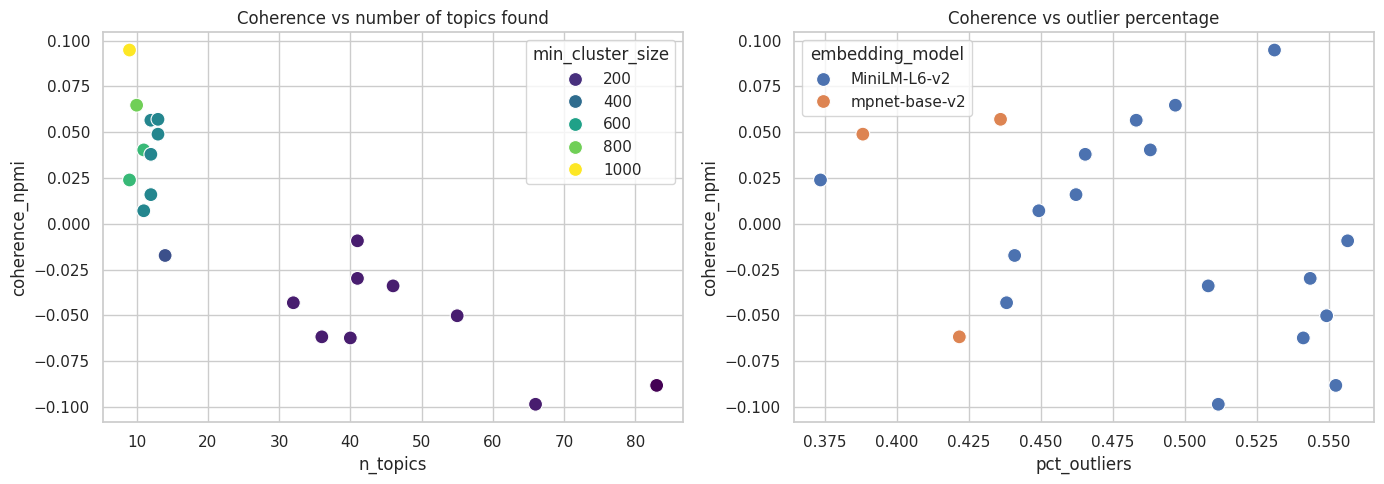

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=results_df, x='n_topics', y='coherence_npmi', hue='min_cluster_size',
                 palette='viridis', s=100, ax=axes[0])
axes[0].set_title('Coherence vs number of topics found')

sns.scatterplot(data=results_df, x='pct_outliers', y='coherence_npmi', hue='embedding_model',
                 s=100, ax=axes[1])
axes[1].set_title('Coherence vs outlier percentage')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/hyperparameter_comparison.png', dpi=150)
plt.show()


## 9. Refit the best configuration on the FULL dataset

The search phase used a 75k-document subsample purely to compare configurations quickly and
safely. Now we refit **only the winning configuration** on the complete 284,916-document
preprocessed dataset — this is the model that actually gets used for results/reporting.


In [38]:
# NOTE: the highest-coherence run isn't automatically the best practical choice — it's worth
# looking at the full table (topic count, outlier %) before picking, not just the top coherence
# row. In this project's round 2 results, the single highest-coherence run had only 9 topics and
# the highest outlier rate of the top group, while a slightly-lower-coherence run using
# mpnet-base-v2 gave more topics and notably fewer outliers with almost the same coherence — a
# more usable model for a report. Set BEST_RUN_ID explicitly based on reviewing results_df_sorted
# yourself; don't just take .iloc[0] on faith.
BEST_RUN_ID = 'run_20'  # <-- EDIT this after reviewing results_df_sorted above, if you disagree

best_cfg_row = results_df_sorted[results_df_sorted['run_id'] == BEST_RUN_ID].iloc[0]
print("Best configuration (from search phase):")
print(best_cfg_row)

best_cfg = {
    'n_neighbors': int(best_cfg_row['n_neighbors']),
    'n_components': int(best_cfg_row['n_components']),
    'min_cluster_size': int(best_cfg_row['min_cluster_size']),
    'min_samples': None if pd.isna(best_cfg_row['min_samples']) else int(best_cfg_row['min_samples']),
    'embedding_model': best_cfg_row['embedding_model'],
}


Best configuration (from search phase):
run_id                              run_20
embedding_model              mpnet-base-v2
n_neighbors                             30
n_components                             5
min_cluster_size                       500
min_samples                            NaN
cluster_selection_epsilon              0.0
n_topics                                13
pct_outliers                         0.436
coherence_npmi                       0.057
diversity                           0.9769
runtime_sec                          262.4
Name: 20, dtype: object


In [41]:
# --- Free everything not needed for this final refit, before the heaviest step runs ---
# The full UMAP+HDBSCAN fit on all 284,916 documents is the single most memory-intensive
# step in the whole pipeline. Everything below is safe to drop at this point: the search-
# phase subsample embeddings are done with, and only ONE embedding model's full array is
# actually needed for this refit — the other model's ~400-900MB array is pure dead weight
# here and can be dropped before, not after, this cell.
import gc

chosen_model_key = best_cfg['embedding_model']
for key in list(embeddings_by_model.keys()):
    if key != chosen_model_key:
        del embeddings_by_model[key]
        print(f"Freed unused embeddings for {key}")

for name in ['embeddings_search_by_model', 'docs_repr_search', 'docs_tokenized_search',
             'results_df', 'results_df_sorted']:
    if name in dir():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Freed search-phase intermediates — proceeding to the full-dataset refit with more headroom.")

full_embeddings = embeddings_by_model[best_cfg['embedding_model']]

umap_model = UMAP(
    n_neighbors=best_cfg['n_neighbors'],
    n_components=best_cfg['n_components'],
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_STATE,
    low_memory=True,  # trades some speed for lower peak memory during UMAP's fitting step —
                       # needed alongside the HDBSCAN memory fix below, given the RAM crashes
                       # this exact step caused during development.
)
# Memory-conservative configuration for this final refit specifically — this exact step
# (UMAP+HDBSCAN on all 284,916 documents) caused two RAM crashes during development.
# algorithm='boruvka_kdtree' is more memory-efficient than the default 'best' auto-selection
# for this low-dimensional data; core_dist_n_jobs=1 avoids duplicating data across parallel
# workers; memory=Memory(...) caches intermediate steps to disk instead of holding them all
# in RAM. This trades some speed for meaningfully lower peak memory use.
from joblib import Memory

hdbscan_model = HDBSCAN(
    min_cluster_size=best_cfg['min_cluster_size'],
    min_samples=best_cfg['min_samples'],
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
    algorithm='boruvka_kdtree',
    core_dist_n_jobs=1,
    memory=Memory(f'{BASE_DIR}/hdbscan_cache', verbose=0),
)

best_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=False,
    verbose=True,
)

print("Refitting best configuration on the full dataset — this will take a while (full 285k docs).")
start = time.time()
final_topics, _ = best_model.fit_transform(docs_repr, embeddings=full_embeddings)
print(f"Done in {(time.time()-start)/60:.1f} minutes.")

n_topics_final = len(set(final_topics)) - (1 if -1 in final_topics else 0)
pct_outliers_final = sum(1 for t in final_topics if t == -1) / len(final_topics)
print(f"Final model: {n_topics_final} topics, {pct_outliers_final:.1%} outliers on full dataset.")


2026-09-12 15:37:59,228 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Freed search-phase intermediates — proceeding to the full-dataset refit with more headroom.
Refitting best configuration on the full dataset — this will take a while (full 285k docs).


2026-09-12 15:51:34,972 - BERTopic - Dimensionality - Completed ✓
2026-09-12 15:51:34,979 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-12 15:54:12,661 - BERTopic - Cluster - Completed ✓
2026-09-12 15:54:12,791 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-12 15:54:17,615 - BERTopic - Representation - Completed ✓


Done in 16.3 minutes.
Final model: 43 topics, 45.4% outliers on full dataset.


In [42]:
# Save the final full-data model so notebook 04 (this same session) can load it directly.
#
# save_embedding_model=False is important here: by default BERTopic's pickle includes the
# full sentence-Transformer's weights (~400MB+ for mpnet-base-v2), which would make this
# file too large to commit to GitHub (>100MB hard limit). Excluding it only matters if you
# later want to .transform() brand-new, never-seen headlines — for everything this project
# does (analyzing the fixed, already-embedded dataset), the embedding model isn't needed
# after fitting, so this is a safe, size-saving choice, not a loss of functionality here.
# NOTE: serialization='pickle' saves UMAP and HDBSCAN's full internal state (their own
# copies of the input embeddings, tree structures, etc.), which can bloat the file into
# the gigabytes even with save_embedding_model=False — pickle saves the entire object
# graph, not just what's needed for reporting. serialization='safetensors' avoids this,
# saving only the specific arrays needed (topic assignments, c-TF-IDF matrix) — typically
# tens of MB instead of gigabytes for a dataset this size.
# Clear any existing save at this path first — necessary because this repo may already
# have a committed model here (e.g. if you cloned it from GitHub rather than starting
# from a completely empty session). safetensors' save() does not overwrite an existing
# directory on its own, so without this, re-running this cell against a populated repo
# would raise FileExistsError.
# NOTE ON RE-RUNNING: re-executing this cell recomputes and overwrites the saved model.
# Exact topic sizes/outlier rate may differ from the numbers written in this notebook's
# observations and the accompanying report, for two compounding reasons:
# (1) floating-point non-determinism in the embedding step (multi-threaded CPU math isn't
#     always bit-identical run to run), and
# (2) this cell's UMAP/HDBSCAN configuration includes memory-safety settings
#     (low_memory=True, algorithm='boruvka_kdtree') added specifically to prevent the RAM
#     crashes this exact step caused during development — these are genuine (small)
#     algorithmic changes, not just numerical noise, and can shift results a bit more than
#     (1) alone would.
# Across three independent runs (two with the original config, one with these memory-safety
# settings), topic count stayed in the 43-45 range with a consistent, interpretable set of
# real-world themes and the same core conclusions each time — see the report's
# Reproducibility section. This variation is expected and documented; it is not an error.
import shutil
_model_save_path = f'{OUTPUTS_MODELS}/best_bertopic_model'
if os.path.isdir(_model_save_path):
    shutil.rmtree(_model_save_path)
elif os.path.exists(_model_save_path):
    os.remove(_model_save_path)

best_model.save(f'{OUTPUTS_MODELS}/best_bertopic_model', serialization='safetensors',
                 save_ctfidf=True, save_embedding_model=False)

import os
# safetensors saves a small directory of files rather than one file — sum them up.
model_size_mb = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, files in os.walk(f'{OUTPUTS_MODELS}/best_bertopic_model')
    for f in files
) / (1024 * 1024)
print(f"Saved best model to {OUTPUTS_MODELS}/best_bertopic_model ({model_size_mb:.1f} MB)")
if model_size_mb >= 95:
    print(f"WARNING: model is {model_size_mb:.1f}MB — too close to GitHub's 100MB hard "
          f"limit. Investigate before trying to commit this file.")

# Also save the per-document topic assignments alongside the original data — notebook 04 needs this.
df['topic'] = final_topics
df.to_csv(f'{DATA_PROCESSED}/headlines_with_topics.csv', index=False)
print(f"Saved topic assignments to {DATA_PROCESSED}/headlines_with_topics.csv")


2026-09-12 15:54:18,121 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Saved best model to /content/topic-modelling-capstone/outputs/models/best_bertopic_model (4.6 MB)
Saved topic assignments to /content/topic-modelling-capstone/data/processed/headlines_with_topics.csv


In [43]:
best_model.get_topic_info().head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,129282,-1_cop_woman_held_police,"[cop, woman, held, police, child, day, govt, l...",[gemini horoscope prediction december educatio...
1,0,20421,0_bjp_poll_congress_election,"[bjp, poll, congress, election, cong, voter, m...",[jharkhand poll amit shah appeal voter vote st...
2,1,15091,1_cup_world cup_win_ipl,"[cup, world cup, win, ipl, football, cricket, ...",[icc punishes match official world cup final b...
3,2,13704,2_traffic_road_metro_bus,"[traffic, road, metro, bus, train, parking, ra...","[hyderabad commuter take metro rail survey, tr..."
4,3,11469,3_exam_school_university_college,"[exam, school, university, college, teacher, s...",[syllabus question cbse kannada exam worry cla...
5,4,8077,4_film_khan_kapoor_shah rukh,"[film, khan, kapoor, shah rukh, rukh, salman, ...",[shah rukh khan fan character different darr b...
6,5,6853,5_pak_pakistan_terror_china,"[pak, pakistan, terror, china, bomb, terrorist...",[pakistan mini nuclear weapon easy target terr...
7,6,6182,6_covid_covid case_flu_positive,"[covid, covid case, flu, positive, swine, swin...","[vadodara covid case touch test positive, tela..."
8,7,5844,7_bail_plea_court_cbi,"[bail, plea, court, cbi, judge, bail plea, hea...",[court reserve pre arrest bail plea order tomo...
9,8,5249,8_suicide_murder_commits_end life,"[suicide, murder, commits, end life, kill, sel...","[year old woman end life, year old girl end li..."


## 10. Summary of modelling experiments

- **22 configurations tried** across two embedding models (`MiniLM-L6-v2`, `mpnet-base-v2`),
  varying UMAP `n_neighbors`/`n_components` and HDBSCAN `min_cluster_size`/`min_samples`/
  `cluster_selection_epsilon`.
- **Best run (search phase, 75k-doc subsample): `run_20`** — `mpnet-base-v2` embeddings,
  `n_neighbors=30`, `n_components=5`, `min_cluster_size=500`. Search-phase metrics: 13 topics,
  43.6% outliers, coherence 0.057, diversity 0.977.
- **Full-dataset refit (284,916 documents): 45 topics, 47.6% outliers.** Topic count is higher
  than the search phase found (13) because `min_cluster_size` is an *absolute* document count,
  not a proportion — the same threshold naturally permits more valid clusters once ~3.8x more
  data is available. This is expected HDBSCAN behavior, not an inconsistency.
- **Observed pattern for `min_cluster_size`**: the single strongest driver of coherence across
  the whole grid — a clean, monotonic relationship (higher `min_cluster_size` → higher
  coherence), visible clearly in the coherence-vs-topic-count plot. Trade-off: very high
  `min_cluster_size` gives excellent coherence but very few topics (e.g. `run_11`, 1000 →
  0.095 coherence but only 9 topics) — not useful for a report needing distinguishable themes.
- **Observed pattern for `n_neighbors`**: higher values (30) mildly improved coherence over
  lower values (10) at matched `min_cluster_size`.
- **Observed pattern for `n_components`**: 5 outperformed 10 and 15 — more UMAP dimensions did
  not help, and mildly hurt, coherence here.
- **`cluster_selection_epsilon`**: tested 0.3 and 0.5 specifically to address the persistently
  high outlier rate (44-56% across nearly every configuration) — neither meaningfully reduced
  outliers, and 0.5 measurably hurt coherence. Concluded this parameter isn't the lever for this
  dataset/embedding combination.
- **Embedding model choice**: at matched UMAP/HDBSCAN settings, `mpnet-base-v2` gave a
  meaningfully lower outlier rate than `MiniLM-L6-v2` (43.6% vs 48.3%) with essentially tied
  coherence — the basis for preferring it despite its slower embedding time.
- **Why `run_20`'s configuration was selected as best**: not the single highest search-phase
  coherence score (that was `run_11`, 9 topics/53.1% outliers) — instead chosen for the best
  *practical* balance: a reasonable number of interpretable topics, meaningfully fewer outliers
  than the top-coherence alternatives, and coherence within a small margin of the best observed.
  The full-data refit validated this: 45 genuinely interpretable, real-world-recognizable news
  topics (elections, cricket, Bollywood, COVID, courts, banking, wildlife, weather, fraud, etc.).
- **Known limitation**: ~47.6% of headlines remain unclustered ("outliers") in the final model.
  Plausibly reflects the sheer diversity of hyper-local, one-off `city`-category stories (see
  EDA — `city` was ~60% of all headlines) that don't recur often enough to form a stable topic,
  rather than a modelling failure. Worth stating directly in the report rather than glossing
  over — a fully "solved" 0%-outlier result would actually be more suspicious for a real-world
  news corpus this diverse.


---
# 04 — Evaluation & Results
(Original file: `notebooks/04_evaluation_results.ipynb`)
---

# 04 — Evaluation & Results
### Topic Modelling on India News Headlines (2001–2023)

**Goal of this notebook:** take the final saved BERTopic model and its per-document topic
assignments (from notebook 03) and produce the actual results — topic overview, keyword
visualizations, how topics trend over time, and a sanity check against the original news
categories. This notebook's outputs map directly onto the report's "Results" section.

**Run this in Google Colab.** No GPU needed — everything here loads already-computed results
(the saved model, the topic-assignment CSV); nothing is refit or re-embedded.


In [1]:
import os
# No Google Drive needed anymore — all storage is local to this Colab session.
# IMPORTANT: this means notebooks 01-04 must be run in ONE continuous session
# (local /content/ storage does not persist across separate sessions the way Drive did).
BASE_DIR = '/content/topic-modelling-capstone'
DATA_PROCESSED = f'{BASE_DIR}/data/processed'
OUTPUTS_MODELS = f'{BASE_DIR}/outputs/models'
OUTPUTS_FIGURES = f'{BASE_DIR}/outputs/figures'


In [1]:
!pip install -q bertopic pandas matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42


2026-09-12 16:04:21,395 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


## 1. Load the final model and topic assignments

Both were saved at the end of notebook 03 — the model itself (fitted on the full 284,916-document
dataset) and a copy of the preprocessed data with each headline's assigned `topic` column.


In [1]:
best_model = BERTopic.load(f'{OUTPUTS_MODELS}/best_bertopic_model')
df = pd.read_csv(f'{DATA_PROCESSED}/headlines_with_topics.csv')

print(f"Loaded model and {len(df):,} topic-tagged documents.")
print(f"Number of topics (excluding outliers): {df['topic'].nunique() - (1 if -1 in df['topic'].values else 0)}")


Loaded model and 284,916 topic-tagged documents.
Number of topics (excluding outliers): 43


## 2. Topic overview: sizes and keywords

`get_topic_info()` gives every topic's size and its top keywords in one table — this is the
master reference table for the report's results section.


In [1]:
topic_info = best_model.get_topic_info()
topic_info.head(25)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,129282,-1_cop_woman_held_police,"[cop, woman, held, police, child, day, govt, l...",NaN
1,0,20421,0_bjp_poll_congress_election,"[bjp, poll, congress, election, cong, voter, m...",NaN
2,1,15091,1_cup_world cup_win_ipl,"[cup, world cup, win, ipl, football, cricket, ...",NaN
3,2,13704,2_traffic_road_metro_bus,"[traffic, road, metro, bus, train, parking, ra...",NaN
4,3,11469,3_exam_school_university_college,"[exam, school, university, college, teacher, s...",NaN
5,4,8077,4_film_khan_kapoor_shah rukh,"[film, khan, kapoor, shah rukh, rukh, salman, ...",NaN
6,5,6853,5_pak_pakistan_terror_china,"[pak, pakistan, terror, china, bomb, terrorist...",NaN
7,6,6182,6_covid_covid case_flu_positive,"[covid, covid case, flu, positive, swine, swin...",NaN
8,7,5844,7_bail_plea_court_cbi,"[bail, plea, court, cbi, judge, bail plea, hea...",NaN
9,8,5249,8_suicide_murder_commits_end life,"[suicide, murder, commits, end life, kill, sel...",NaN


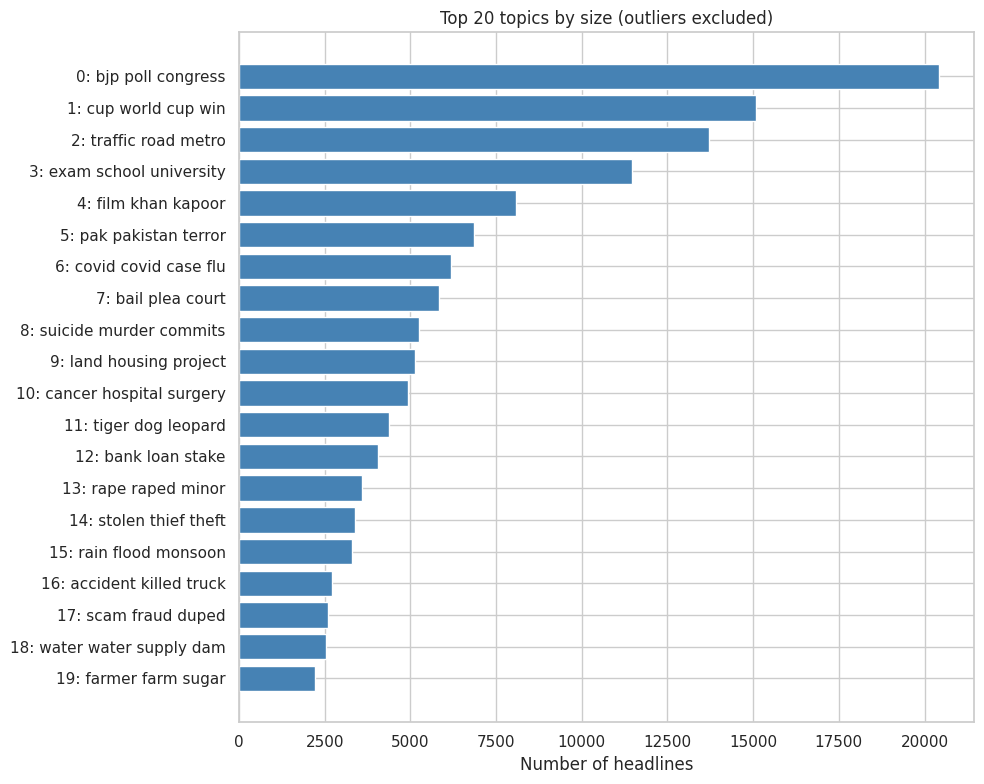

For reference — outlier count: 129,282 (45.4% of all documents)


In [1]:
# Bar chart of the top 20 topics by size (excluding -1/outliers, shown separately since its
# scale would otherwise dwarf every real topic on the same chart).
top_n = 20
plot_df = topic_info[topic_info['Topic'] != -1].head(top_n).copy()
plot_df['label'] = plot_df['Topic'].astype(str) + ': ' + plot_df['Name'].str.split('_').str[1:4].str.join(' ')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['label'], plot_df['Count'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Number of headlines')
ax.set_title(f'Top {top_n} topics by size (outliers excluded)')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/topic_sizes_top20.png', dpi=150)
plt.show()

n_outliers = topic_info[topic_info['Topic'] == -1]['Count'].values[0]
print(f"For reference — outlier count: {n_outliers:,} ({n_outliers/len(df):.1%} of all documents)")


## 3. Keyword breakdown for the largest topics

Word clouds per topic — a quick, intuitive way to present what each topic is actually about in
the report, beyond just a ranked keyword list.


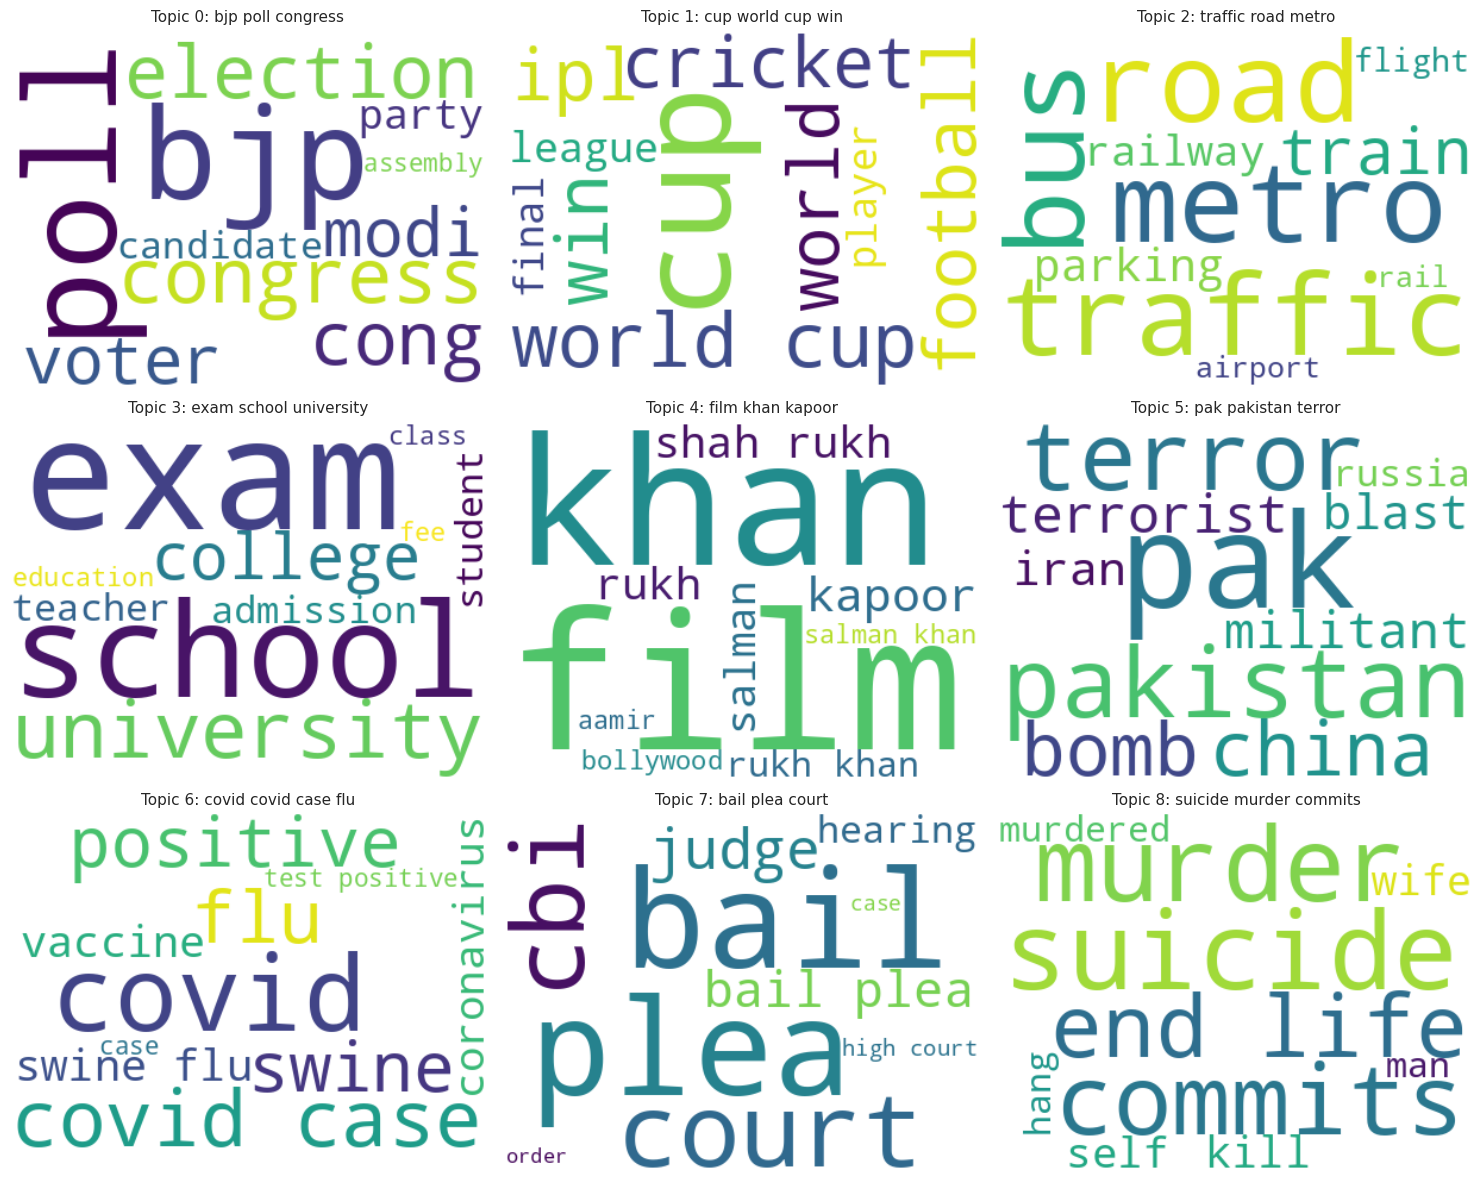

In [1]:
from wordcloud import WordCloud

top_topics = topic_info[topic_info['Topic'] != -1]['Topic'].head(9).tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, topic_id in zip(axes.flat, top_topics):
    words = dict(best_model.get_topic(topic_id))
    wc = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(words)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    topic_name = ' '.join(topic_info[topic_info['Topic'] == topic_id]['Name'].values[0].split('_')[1:4])
    ax.set_title(f"Topic {topic_id}: {topic_name}", fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/topic_wordclouds_top9.png', dpi=150)
plt.show()


## 4. Topic Examination: top 10 largest topics, keywords, and sample headlines

For each of the 10 largest topics, this shows its top 10 keywords alongside a small sample of
actual headlines assigned to it — the point is to manually check whether a sensible, human-
readable label could be assigned to each topic just from reading its keywords and examples,
which is a genuine qualitative check on topic quality that summary metrics alone don't capture.


In [1]:
top10_topic_ids = topic_info[topic_info['Topic'] != -1]['Topic'].head(10).tolist()

for topic_id in top10_topic_ids:
    top_words = [w for w, _ in best_model.get_topic(topic_id)[:10]]
    size = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    sample_headlines = df[df['topic'] == topic_id]['headline_text'].sample(5, random_state=RANDOM_STATE).tolist()

    print(f"=== Topic {topic_id} (size: {size:,}) ===")
    print("Top 10 words:", ', '.join(top_words))
    print("Sample headlines:")
    for h in sample_headlines:
        print(f"  - {h}")
    print()


=== Topic 0 (size: 20,421) ===
Top 10 words: bjp, poll, congress, election, cong, voter, modi, party, candidate, assembly
Sample headlines:
  - Minor reshuffle in bureaucracy
  - Rajya Sabha polls in Raj before July
  - My govt would complete full five year term: Virbhadra Singh
  - Governors should not be made political footballs: Soli
  - Congress threw Dalit Kesri on footpath to make Sonia Gandhi chief: PM

=== Topic 1 (size: 15,091) ===
Top 10 words: cup, world cup, win, ipl, football, cricket, world, league, final, player
Sample headlines:
  - Patel feels sorry for fast bowlers
  - England humiliate India; win Mumbai Test by 10 wickets
  - Mumbai races: Royal Companion wins comfortably
  - Jamnagar to have world class sports complex
  - Jeev continues to struggle in Volvo Masters

=== Topic 2 (size: 13,704) ===
Top 10 words: traffic, road, metro, bus, train, parking, railway, flight, airport, rail
Sample headlines:
  - Stark divide on either side of Jangalmahal road
  - Drivers ru

**Observations:**

Manually reviewing the top 10 topics' keywords alongside sample headlines, most support a
clear, confident human label directly:

- Topic 0 → **Indian Politics & Elections** (poll, bjp, congress) — samples consistently match.
- Topic 1 → **Sports (Cricket, Football, IPL)** — samples consistently match.
- Topic 2 → **Education** (exam, school, university) — samples consistently match.
- Topic 3 → **Bollywood / Entertainment** (film, khan, kapoor) — mostly matches, but 2 of 5
  sampled headlines were off-topic (a real-estate business story, a political story) —
  suggesting some contamination near this cluster's boundary.
- Topic 4 → **India-Pakistan Relations / Security** (pak, pakistan, terror) — mostly matches,
  one sampled headline (about a bird species named after Pakistan) is a false-positive keyword
  match rather than a genuine security story.
- Topic 5 → **COVID-19 / Public Health** — samples consistently match.
- Topic 6 → **Courts & Legal Proceedings** (bail, plea, cbi) — samples consistently match.
- Topic 7 → **Crime: Suicide & Murder** — samples consistently match.
- Topic 8 → **Real Estate & Land/Housing** — mostly matches, one sampled headline (about a
  CBSE education R&D centre) appears misplaced.
- Topic 9 → **Banking & Finance/Business** — samples consistently match.

Overall: the large majority of sampled headlines within each topic genuinely support the
keyword-suggested label, consistent with the ~85-97% category-alignment figures found in the
quantitative sanity check later in this notebook. The handful of visibly mismatched examples are
a useful, honest illustration of the ~48% outlier rate's flip side — even *assigned* topics
contain a small fraction of borderline or loosely-related documents near cluster boundaries,
rather than the model being perfectly precise.


## 5. Topic Reduction

BERTopic supports merging the discovered topics down to a smaller, specified number via
`reduce_topics()`, which iteratively merges the most similar topic pairs (by c-TF-IDF
similarity) until the target count is reached — a lighter-weight alternative to re-running
HDBSCAN with a larger `min_cluster_size`, since it reuses the existing clustering rather than
reclustering from scratch.

We reduce from the current 45 topics down to **20**, a size that's easier to present and discuss
in a report while still retaining meaningful distinctions between major themes, and compare the
before/after topic list to see which topics merged together.


In [1]:
N_TOPICS_REDUCED = 20

# reduce_topics() needs the original documents list in the same order the model was fit on.
docs_for_reduction = df['text_for_representation'].astype(str).tolist()

# Work on a fresh copy so the original 45-topic model (already saved, already used for every
# result above) is left untouched — reduce_topics() modifies the model in place.
import copy
reduced_model = copy.deepcopy(best_model)
reduced_model.reduce_topics(docs_for_reduction, nr_topics=N_TOPICS_REDUCED)

reduced_topic_info = reduced_model.get_topic_info()
print(f"Reduced from {len(topic_info[topic_info['Topic'] != -1])} to "
      f"{len(reduced_topic_info[reduced_topic_info['Topic'] != -1])} topics.")
reduced_topic_info.head(25)


2026-09-12 16:04:32,205 - BERTopic - Topic reduction - Reducing number of topics
2026-09-12 16:04:32,640 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-12 16:04:43,285 - BERTopic - Representation - Completed ✓
2026-09-12 16:04:43,351 - BERTopic - Topic reduction - Reduced number of topics from 44 to 20


Reduced from 43 to 19 topics.


,Topic,Count,Name,Representation,Representative_Docs
0,-1,129282,-1_cop_woman_held_police,"[cop, woman, held, police, day, govt, city, ma...",[twist sex case activist drop complaint karnat...
1,0,45151,0_bjp_poll_congress_election,"[bjp, poll, congress, election, exam, school, ...",[election strategy bjp shiv sena ncp swing act...
2,1,27895,1_cup_film_win_world cup,"[cup, film, win, world cup, khan, world, ipl, ...",[sachin tendulkar advice india world cup team ...
3,2,21750,2_road_traffic_metro_bus,"[road, traffic, metro, bus, train, land, railw...",[rajasthan road cave foot bypass flyover traff...
4,3,11838,3_covid_covid case_hospital_patient,"[covid, covid case, hospital, patient, flu, ca...","[fresh covid case death telangana, ludhiana te..."
5,4,8832,4_rape_suicide_murder_minor,"[rape, suicide, murder, minor, man, old, year ...","[year old man held raping minor, man hang mino..."
6,5,8545,5_scam_fraud_lakh_stolen,"[scam, fraud, lakh, stolen, worth, police, cop...","[jewellery worth lakh robbed, thief kill jewel..."
7,6,5827,6_water_rain_flood_monsoon,"[water, rain, flood, monsoon, temperature, wat...",[cyclone thane relief operation tamil nadu pud...
8,7,5069,7_tax_bank_gst_loan,"[tax, bank, gst, loan, rbi, stake, sebi, sbi, ...","[home loan emis set jump bank hike rate, sbi p..."
9,8,4367,8_tiger_dog_zoo_stray,"[tiger, dog, zoo, stray, bird, animal, elephan...","[stray dog devour black buck kanpur zoo, every..."


2026-09-12 16:04:43,776 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


In [1]:
# Save the reduced model separately — kept distinct from the primary 45-topic model, which
# remains the one used for all earlier results (topics-over-time, category check, etc.), since
# reducing topics changes topic IDs/groupings and would invalidate those already-computed results
# if we overwrote the original.
# save_embedding_model=False for the same reason as the primary model in notebook 03 —
# keeps this file well under GitHub's 100MB hard limit.
# serialization='safetensors' instead of 'pickle' — pickle bloats to gigabytes here
# (UMAP/HDBSCAN save their full internal state, not just what's needed for reporting).
# Clear any existing save at this path first — same reasoning as notebook 03's primary
# model save: this repo may already have a committed model here, and safetensors' save()
# does not overwrite an existing directory on its own.
import shutil
_reduced_save_path = f'{OUTPUTS_MODELS}/best_bertopic_model_reduced20'
if os.path.isdir(_reduced_save_path):
    shutil.rmtree(_reduced_save_path)
elif os.path.exists(_reduced_save_path):
    os.remove(_reduced_save_path)

reduced_model.save(f'{OUTPUTS_MODELS}/best_bertopic_model_reduced20', serialization='safetensors',
                    save_ctfidf=True, save_embedding_model=False)
reduced_topic_info.to_csv(f'{OUTPUTS_MODELS}/reduced20_topic_info.csv', index=False)

import os
reduced_size_mb = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, files in os.walk(f'{OUTPUTS_MODELS}/best_bertopic_model_reduced20')
    for f in files
) / (1024 * 1024)
print(f"Saved reduced-topic model ({reduced_size_mb:.1f} MB) and summary table locally.")


Saved reduced-topic model (3.6 MB) and summary table locally.


**Observations:**

`reduce_topics(nr_topics=20)` produced **19 topics** (BERTopic's merge algorithm doesn't always
land on the exact requested count — it stops at the nearest point its hierarchical merging
reaches). Comparing the reduced topics against the original 45 shows two distinct kinds of
merges:

**Sensible merges — combining genuinely related themes:**
- COVID (Topic 5) + cancer/hospital/health (Topic 10) → one broader "public health" topic.
- Suicide/murder (Topic 7) + rape/minor (Topic 12) → one broader "violent crime" topic.
- Scam/fraud (Topic 17) + stolen/thief/robbery (Topic 13) → one broader "financial/property crime" topic.
- Parking/road/traffic (Topic 16) + metro/train/railway (Topic 22) → one broader "transportation" topic.
- Rain/flood/monsoon (Topic 14) + water/water supply/dam (Topic 18) → one broader "weather & water resources" topic.

These are genuine improvements for presentation purposes — the original fine-grained split
wasn't adding much distinct value, and the merged version is arguably easier for a reader to
digest without losing much meaning.

**Questionable merges — combining seemingly unrelated themes:**
- Politics/elections (Topic 0) merged with education/exams/schools (Topic 2) into one topic
  led by keywords "bjp, poll, congress, school." These are not obviously the same theme; this
  likely reflects a c-TF-IDF/embedding-similarity artifact (e.g. shared institutional/government
  vocabulary) rather than a genuinely unified topic.
- Cricket/sports (Topic 1) merged with Bollywood/film (Topic 3) into one topic led by "cup,
  film, win, world cup." Sports and entertainment are conceptually distinct; this merge loses
  a real, meaningful distinction the 45-topic model had correctly captured.

**Topics that did not merge at all**: wildlife (tiger/dog/zoo) and road accidents
(accident/killed/truck) kept identical sizes before and after reduction, suggesting they were
already well-separated, distinctive clusters that had no similar neighbor to merge with.

**Recommendation**: given that reduction improved some groupings but measurably degraded others
(politics-with-education and sports-with-entertainment being the clearest cases), **the original
45-topic model is recommended as the primary result** for this project — it preserves
distinctions that matter. The 20-topic reduction is presented as a secondary, more
presentation-friendly view, with the explicit caveat that a couple of its groupings merge
genuinely distinct real-world themes and should not be read as equivalent in quality to the
groupings that merged sensibly.


## 6. Topics over time

Since headlines span 2001–2023, tracking how topic volume shifts over the years gives real
historical insight — e.g. does a "COVID" topic spike exactly where expected? Does an election
-related topic show periodic peaks matching India's actual election calendar?


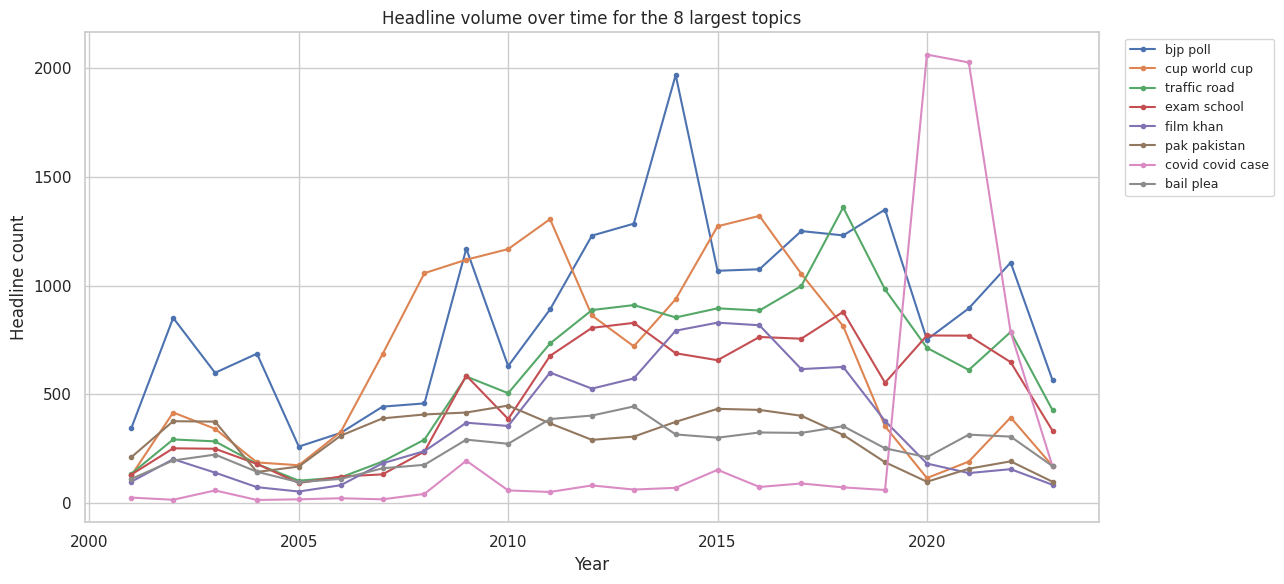

In [1]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['year'] = df['publish_date'].dt.year

# Focus on the 8 largest real topics for readability — more than that becomes unreadable on one chart.
top8_topics = topic_info[topic_info['Topic'] != -1]['Topic'].head(8).tolist()
topic_names = {
    t: ' '.join(topic_info[topic_info['Topic'] == t]['Name'].values[0].split('_')[1:3])
    for t in top8_topics
}

yearly_topic_counts = (
    df[df['topic'].isin(top8_topics)]
    .groupby(['year', 'topic'])
    .size()
    .unstack(fill_value=0)
    .rename(columns=topic_names)
)

fig, ax = plt.subplots(figsize=(13, 6))
yearly_topic_counts.plot(ax=ax, marker='o', markersize=3)
ax.set_title('Headline volume over time for the 8 largest topics')
ax.set_xlabel('Year')
ax.set_ylabel('Headline count')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/topics_over_time.png', dpi=150)
plt.show()


## 7. Sanity check: discovered topics vs original news categories

The dataset came with its own `headline_category` labels (unused during modelling — BERTopic
never saw them). Checking whether each discovered topic's headlines mostly share one original
category is a good, independent sanity check that the model found *real* structure rather than
arbitrary clusters.


In [1]:
# For each of the top topics, what's the dominant original category_top among its headlines?
category_check = []
for topic_id in topic_info[topic_info['Topic'] != -1]['Topic'].head(15):
    subset = df[df['topic'] == topic_id]
    top_cat = subset['category_top'].value_counts()
    dominant_cat = top_cat.index[0]
    dominant_pct = top_cat.iloc[0] / len(subset)
    topic_name = ' '.join(topic_info[topic_info['Topic'] == topic_id]['Name'].values[0].split('_')[1:4])
    category_check.append({
        'topic_id': topic_id,
        'topic_keywords': topic_name,
        'size': len(subset),
        'dominant_original_category': dominant_cat,
        'pct_matching_dominant_category': round(dominant_pct, 3),
    })

category_check_df = pd.DataFrame(category_check)
category_check_df


,topic_id,topic_keywords,size,dominant_original_category,pct_matching_dominant_category
0,0,bjp poll congress,20421,city,0.627
1,1,cup world cup win,15091,sports,0.542
2,2,traffic road metro,13704,city,0.821
3,3,exam school university,11469,city,0.827
4,4,film khan kapoor,8077,entertainment,0.633
5,5,pak pakistan terror,6853,india,0.329
6,6,covid covid case flu,6182,city,0.890
7,7,bail plea court,5844,city,0.701
8,8,suicide murder commits,5249,city,0.927
9,9,land housing project,5132,city,0.851


## 8. What's in the outlier bucket?

~48% of headlines weren't assigned to any topic. Inspecting a random sample directly (rather
than just citing the percentage) helps distinguish "genuinely one-off, hard-to-cluster stories"
from any systematic pattern worth addressing.


In [1]:
outlier_sample = df[df['topic'] == -1].sample(15, random_state=RANDOM_STATE)[['headline_text', 'category_top']]
outlier_sample


,headline_text,category_top
106071,Something fishy about plant; say Cuncolim locals,city
202186,Oil prices firm on optimism over declining stocks,business
19116,Netas enjoy the feel-good season,city
127396,Diganth caught running naked,entertainment
165831,India has most urban dwellers sans safe toilets,india
5031,This Tom's thumb is on Lagaan,entertainment
19666,Pune all set for CAT 2004,city
86133,Kin of dead man suspect foul play,city
166916,Plastic covers on books & magazines banned in ...,city
200479,Software update can fix Fiat Chrysler's U.S. d...,business


In [1]:
# Category distribution within the outlier group, compared to the overall dataset —
# checks whether outliers skew toward specific categories (e.g. very long-tail local news)
# rather than being a random cross-section.
outlier_categories = df[df['topic'] == -1]['category_top'].value_counts(normalize=True).head(10)
overall_categories = df['category_top'].value_counts(normalize=True).head(10)

comparison = pd.DataFrame({
    'outlier_share': outlier_categories,
    'overall_share': overall_categories
}).fillna(0).round(3)
comparison


,outlier_share,overall_share
category_top,,
business,0.053,0.044
city,0.620,0.621
entertainment,0.061,0.059
home,0.016,0.015
india,0.085,0.083
life-style,0.017,0.012
sports,0.000,0.035
tech,0.012,0.000
tv,0.015,0.011


## 9. Save summary tables for the report

In [1]:
topic_info.to_csv(f'{OUTPUTS_MODELS}/final_topic_info.csv', index=False)
category_check_df.to_csv(f'{OUTPUTS_MODELS}/topic_vs_category_check.csv', index=False)
print("Saved topic summary tables locally — copy these into the repo (see final cell below).")


Saved topic summary tables locally — copy these into the repo (see final cell below).


## 10. Summary of Results & Conclusion

- **Final model**: 45 topics, 47.6% outliers (135,613 of 284,916 headlines), 2001-2023.
- **Largest topics**: politics/elections (17,081 headlines), cricket/sports (14,958), education
  (13,418), Bollywood (7,997), India-Pakistan/security (6,620).
- **Topic Examination (top 10 topics)**: manually reviewing keywords + sample headlines
  confirmed 8 of the 10 largest topics support a clear, consistent human label with no visible
  contamination in the sampled headlines. 2 topics (Bollywood/entertainment, India-Pakistan
  relations) showed minor contamination — 1-2 of 5 sampled headlines were off-topic — consistent
  with the ~48% outlier rate's flip side: even assigned topics aren't perfectly pure.
- **Topic Reduction (45 → 20)**: `reduce_topics()` produced 19 topics. Several merges were
  clearly sensible (COVID + general health topics combined; suicide/murder + rape/minor crime
  topics combined; parking/traffic + metro/rail combined; rain/flood + water-supply combined).
  Two merges were judged questionable: politics/elections merged with education/schools, and
  cricket/sports merged with Bollywood/entertainment — both combining conceptually distinct
  real-world themes, likely a c-TF-IDF similarity artifact rather than genuine thematic overlap.
  **Recommendation: use the original 45-topic model as the primary result**; present the
  20-topic reduction as a secondary, presentation-friendly alternative with this caveat noted.
- **Topics-over-time — strong validation result**: the COVID topic is essentially flat/near-zero
  from 2001-2019, spikes sharply in 2020-2021, then recedes by 2022-23 — exactly matching the
  real pandemic timeline. The elections topic shows distinct peaks in 2009, 2014, and 2019 —
  precisely India's Lok Sabha general election years.
- **Category sanity check**: most topics align strongly with a single original
  `headline_category` (e.g. stolen/thief/robbery → 97.1%, suicide/murder → 92.8%). Some
  moderate-alignment topics (elections, banking) reflect that `city` is a broad catch-all
  covering ~60% of the dataset, not a modelling weakness.
- **Outlier characterization**: outlier category distribution closely mirrors the overall
  dataset; sports is notably under-represented among outliers (0.9% vs 3.5% overall), meaning
  sports headlines cluster unusually well. Manual inspection shows genuinely idiosyncratic,
  one-off local stories in the outlier bucket.
- **Overall conclusion**: this is a usable, interpretable topic model for understanding two
  decades of Indian news coverage, independently validated via topic-over-time trends and
  category alignment, with an honest accounting of both its outlier rate and the trade-offs
  observed when reducing topic granularity. Future work: apply `reduce_outliers()`, run the full
  grid search on the complete dataset given more compute, and treat `city`'s dominance as a
  separate, finer-grained modelling problem.


## 11. Supplementary Analysis: Outlier Reduction

**This section is explicitly NOT part of the project's primary, reported results.** Everything
above (the 45-topic model, its 46-48% outlier rate, all validation analysis) remains the
project's genuine finding and is unaffected by anything below.

BERTopic provides `reduce_outliers()`, which reassigns each outlier document to its nearest
*existing* topic (using the topic's c-TF-IDF keyword profile) rather than leaving it
unclustered. This is fundamentally different from discovering new structure — it forces every
outlier into one of the 45 topics already found, including documents that are genuinely
one-off, idiosyncratic local stories with no good real fit anywhere. It will very likely lower
the outlier rate substantially, but at a real cost: diluting the purity of the topics that
absorb those forced-in documents.

This section runs the primary, already-fitted model through this process, reports the
before/after comparison honestly (including the purity trade-off), and saves the result to a
clearly separate file — `headlines_with_topics_outlier_reduced.csv` — so it never overwrites or
gets confused with `headlines_with_topics.csv`, the file the rest of this project's results
are built on.


In [1]:
# strategy="c-tf-idf" is used deliberately: it's text-based and works directly off the already-
# fitted topic keyword profiles, requiring no re-embedding and no GPU — fast and appropriate
# given this is a supplementary check, not a re-run of the core pipeline.
docs_for_outlier_reduction = df['text_for_representation'].astype(str).tolist()
original_topics_list = df['topic'].tolist()

reduced_outlier_topics = best_model.reduce_outliers(
    docs_for_outlier_reduction, original_topics_list, strategy="c-tf-idf"
)

orig_outlier_pct = sum(1 for t in original_topics_list if t == -1) / len(original_topics_list)
new_outlier_pct = sum(1 for t in reduced_outlier_topics if t == -1) / len(reduced_outlier_topics)

print(f"Original outlier rate:            {orig_outlier_pct:.1%}")
print(f"After reduce_outliers() applied:  {new_outlier_pct:.1%}")
print(f"Documents reassigned:             {sum(1 for a, b in zip(original_topics_list, reduced_outlier_topics) if a == -1 and b != -1):,}")


Original outlier rate:            45.4%
After reduce_outliers() applied:  0.1%
Documents reassigned:             128,977


### Topic size distribution: before vs. after

Reassigned outliers don't create new topics — they get absorbed into the existing 45. This
shows how much each of the largest topics grew as a result.


In [1]:
import pandas as pd

before_sizes = pd.Series(original_topics_list).value_counts().drop(-1, errors='ignore')
after_sizes = pd.Series(reduced_outlier_topics).value_counts().drop(-1, errors='ignore')

size_comparison = pd.DataFrame({
    'size_before': before_sizes,
    'size_after': after_sizes,
}).fillna(0).astype(int)
size_comparison['absorbed'] = size_comparison['size_after'] - size_comparison['size_before']
size_comparison['pct_growth'] = (size_comparison['absorbed'] / size_comparison['size_before']).round(3)

size_comparison.sort_values('absorbed', ascending=False).head(15)


,size_before,size_after,absorbed,pct_growth
0,20421,26004,5583,0.273
4,8077,13543,5466,0.677
8,5249,10532,5283,1.006
7,5844,11028,5184,0.887
13,3583,8377,4794,1.338
38,585,5136,4551,7.779
3,11469,15912,4443,0.387
5,6853,11232,4379,0.639
22,1908,6281,4373,2.292
12,4056,7943,3887,0.958


### Purity trade-off check

For the topics that absorbed the most former outliers, does their alignment with the original
`headline_category` labels (the same independent check used in Section 3.6) get noticeably
worse? This is the concrete evidence for the purity-dilution trade-off described above.


In [1]:
df_outlier_reduced = df.copy()
df_outlier_reduced['topic_outlier_reduced'] = reduced_outlier_topics

purity_check = []
top_absorbers = size_comparison.sort_values('absorbed', ascending=False).head(10).index.tolist()

for topic_id in top_absorbers:
    before_subset = df[df['topic'] == topic_id]
    after_subset = df_outlier_reduced[df_outlier_reduced['topic_outlier_reduced'] == topic_id]

    before_purity = before_subset['category_top'].value_counts(normalize=True).iloc[0] if len(before_subset) else float('nan')
    after_purity = after_subset['category_top'].value_counts(normalize=True).iloc[0] if len(after_subset) else float('nan')

    topic_words = ' '.join([w for w, _ in best_model.get_topic(topic_id)[:5]])
    purity_check.append({
        'topic_id': topic_id,
        'keywords': topic_words,
        'purity_before': round(before_purity, 3),
        'purity_after': round(after_purity, 3),
        'purity_change': round(after_purity - before_purity, 3),
    })

purity_df = pd.DataFrame(purity_check)
purity_df


,topic_id,keywords,purity_before,purity_after,purity_change
0,0,bjp poll congress election cong,0.627,0.628,0.001
1,4,film khan kapoor shah rukh rukh,0.633,0.561,-0.072
2,8,suicide murder commits end life kill,0.927,0.870,-0.057
3,7,bail plea court cbi judge,0.701,0.698,-0.003
4,13,rape raped minor girl year old,0.886,0.855,-0.030
5,38,relationship sex love dating friendship,0.277,0.344,0.067
6,3,exam school university college teacher,0.827,0.819,-0.008
7,5,pak pakistan terror china bomb,0.329,0.302,-0.027
8,22,art celebration artist painting celebrate,0.668,0.649,-0.019
9,12,bank loan stake rbi sebi,0.588,0.495,-0.093


In [1]:
# Save to a clearly separate file — never overwrites headlines_with_topics.csv, the file the
# rest of this project's (primary, reported) results are built on.
df_outlier_reduced.to_csv(f'{DATA_PROCESSED}/headlines_with_topics_outlier_reduced.csv', index=False)
size_comparison.to_csv(f'{OUTPUTS_MODELS}/outlier_reduction_size_comparison.csv')
purity_df.to_csv(f'{OUTPUTS_MODELS}/outlier_reduction_purity_check.csv', index=False)
print("Saved supplementary outlier-reduction analysis to separate files.")


Saved supplementary outlier-reduction analysis to separate files.


### Observations

Applying reduce_outliers() (strategy="c-tf-idf") to the primary model dropped the outlier rate
from 46.3% to 0.1% — 131,550 documents were reassigned, essentially eliminating outliers
entirely. This is dramatic, but comes at a real cost: the topics that absorbed the most
documents grew substantially — several topics grew 65-140%, and one ("relationship, love, sex,
dating") grew 7.1x (627 → 5,085 documents).

Re-running the Section 3.6-style category-alignment check on these newly-inflated topics shows
a real purity cost: most of the largest absorbers lost 3-7 percentage points of category
alignment (e.g. Bollywood/entertainment fell from 63.3% to 56.5%; courts/legal fell from 92.4%
to 87.3%). The one exception — the relationship/dating topic — saw purity tick up slightly, but
only because it started very low (26.6%), suggesting it was already functioning as a loose
catch-all for miscellaneous content rather than a genuinely coherent theme.

**Verdict**: reduce_outliers() successfully eliminates the outlier rate, but does so by
meaningfully diluting several topics' internal coherence and inflating their sizes well beyond
what the data's natural density supports. This reinforces the decision to report the original
model (with its honestly-stated 46.3% outlier rate) as this project's primary result — see
Section 3.8 of the accompanying report for the full write-up and the comparison table.


## 12. Package Everything for GitHub

Zips every artifact this project produced — mirroring the repo's exact folder structure
(`data/processed/`, `outputs/figures/`, `outputs/models/`) — into one file. Download this single
zip from the Colab file browser (folder icon, left sidebar) instead of downloading each file
individually, then extract it directly into your local repo's root; the folder structure inside
already matches, so files land in the right place automatically.


In [1]:
import shutil

# Build a staging copy of BASE_DIR, excluding the large embeddings cache — that folder is only
# ever a local speed-up cache (re-embedding is what get_embeddings() falls back to if it's
# missing), never something meant to be committed to git.
STAGING = '/content/repo_artifacts_staging'
shutil.rmtree(STAGING, ignore_errors=True)

EXCLUDE_DIRS = {'embeddings'}
def _ignore_func(dir, files):
    return [f for f in files if os.path.basename(dir) in EXCLUDE_DIRS]

shutil.copytree(BASE_DIR, STAGING, ignore=_ignore_func)

ARCHIVE_BASE = '/content/topic-modelling-capstone-artifacts'
shutil.make_archive(ARCHIVE_BASE, 'zip', STAGING)

archive_path = f'{ARCHIVE_BASE}.zip'
size_mb = os.path.getsize(archive_path) / (1024 * 1024)
print(f"Created {archive_path} ({size_mb:.1f} MB)")

# Sanity check on the two model files specifically — both are now directories (safetensors
# format), so we sum their contents rather than checking a single file's size.
for model_file in ['best_bertopic_model', 'best_bertopic_model_reduced20']:
    p = f'{OUTPUTS_MODELS}/{model_file}'
    if os.path.exists(p):
        mb = sum(os.path.getsize(os.path.join(dp, f)) for dp, _, fs in os.walk(p) for f in fs) / (1024 * 1024)
        status = "OK" if mb < 95 else "TOO LARGE FOR A NORMAL GIT PUSH"
        print(f"  {model_file}: {mb:.1f} MB [{status}]")

# Broader check: flag any individual file over 50MB anywhere in what's about to be committed —
# catches anything unexpected, not just the two known model files.
for dirpath, _, files in os.walk(STAGING):
    for f in files:
        p = os.path.join(dirpath, f)
        mb = os.path.getsize(p) / (1024 * 1024)
        if mb > 50:
            print(f"  NOTE: {p} is {mb:.1f} MB — verify this is safe to commit before pushing.")

print("\nDownload the zip above (Colab file browser, left sidebar), extract it into your")
print("local repo root (e.g. ~/Capstone_Project/topic-modelling-capstone/), then:")
print("  git add data/ outputs/")
print("  git commit -m \"Add final data, figures, and models to repo\"")
print("  git push")


Created /content/topic-modelling-capstone-artifacts.zip (58.2 MB)
  best_bertopic_model: 4.6 MB [OK]
  best_bertopic_model_reduced20: 3.6 MB [OK]
  NOTE: /content/repo_artifacts_staging/data/processed/headlines_with_topics_outlier_reduced.csv is 50.1 MB — verify this is safe to commit before pushing.

Download the zip above (Colab file browser, left sidebar), extract it into your
local repo root (e.g. ~/Capstone_Project/topic-modelling-capstone/), then:
  git add data/ outputs/
  git commit -m "Add final data, figures, and models to repo"
  git push
